#1 Εισαγωγή και εγκατάσταση βιβλιοθηκών

In [5]:
# 1 Google Ads PMAX Asset Generation & Evaluation (Greek)

# Εγκατάσταση απαραίτητων βιβλιοθηκών
!pip install anthropic pandas google-auth google-auth-oauthlib google-auth-httplib2 google-api-python-client gspread nltk textblob emoji gspread_pandas

import os
import json
import re
import pandas as pd
import numpy as np
import warnings
import time
import random
from io import StringIO
import nltk
from nltk.tokenize import word_tokenize
import requests
import anthropic
from google.colab import auth, files
from google.oauth2.service_account import Credentials
import gspread
from gspread_pandas import Spread

# Αγνόηση προειδοποιήσεων
warnings.filterwarnings('ignore')

# Λήψη απαραίτητων πακέτων NLTK
nltk.download('punkt', quiet=True)

def setup_nltk():
    """Προετοιμασία NLTK για ελληνική γλώσσα"""
    import nltk

    # Κατέβασμα των βασικών πακέτων
    nltk.download('punkt')
    nltk.download('stopwords')

    # Δημιουργία απλού tokenizer για ελληνικά
    from nltk.tokenize import RegexpTokenizer
    # Αυτός ο tokenizer δεν απαιτεί το punkt_tab
    greek_tokenizer = RegexpTokenizer(r'\w+')

    # Προσπάθεια φόρτωσης ελληνικών stopwords, με fallback
    try:
        greek_stopwords = set(nltk.corpus.stopwords.words('greek'))
    except:
        # Fallback αν δεν υπάρχουν ελληνικά stopwords
        greek_stopwords = set(['και', 'ή', 'με', 'σε', 'από', 'για', 'την', 'το',
                              'του', 'της', 'τα', 'των', 'τους', 'τις', 'είναι',
                              'δεν', 'στο', 'στον', 'στη', 'στην', 'στα', 'που'])

    return greek_tokenizer, greek_stopwords

# Κλήση της συνάρτησης
greek_tokenizer, greek_stopwords = setup_nltk()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 2 Συνάρτηση για τη ρύθμιση του Claude API Client


In [6]:
# 2 Συνάρτηση για τη ρύθμιση του Claude API Client
def setup_claude_api(api_key):
    """Δημιουργεί και επιστρέφει ένα αντικείμενο Claude API client"""
    client = anthropic.Anthropic(api_key=api_key)
    return client

# Εισαγωγή API key
import getpass

# Εισαγωγή API Key
print("Εισάγετε το API key του Claude:")
CLAUDE_API_KEY = getpass.getpass()

# Δημιουργία client
try:
    claude_client = setup_claude_api(CLAUDE_API_KEY)
    print("Επιτυχής σύνδεση με το Claude API!")
except Exception as e:
    print(f"Σφάλμα κατά τη σύνδεση με το Claude API: {e}")

Εισάγετε το API key του Claude:
··········
Επιτυχής σύνδεση με το Claude API!


# 3 Υλοποίηση εποπτευόμενου μοντέλου ανάλυσης συναισθήματος για valence και arousal


In [7]:
# 3 Υλοποίηση εποπτευόμενου μοντέλου ανάλυσης συναισθήματος για valence και arousal

import pandas as pd
import numpy as np
import re
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from google.colab import drive
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Αγνόηση προειδοποιήσεων για καθαρότερη έξοδο
warnings.filterwarnings('ignore')

## 3.1 Φόρτωση του ελληνικού λεξικού συναισθημάτων


In [23]:
# 3.1 Φόρτωση του ελληνικού λεξικού συναισθημάτων
def load_greek_sentiment_lexicon(filepath=None):
    """
    Φορτώνει το λεξικό συναισθηματικής ανάλυσης από .tsv αρχείο
    """
    if filepath is None:
        print("Παρακαλώ ανεβάστε το αρχείο λεξικού συναισθημάτων (.tsv)")
        from google.colab import files
        uploaded = files.upload()

        if not uploaded:
            print("Δεν ανεβάστηκε αρχείο. Χρήση προεπιλεγμένου συμπτυγμένου λεξικού.")
            return create_fallback_lexicon()

        filepath = next(iter(uploaded))

    try:
        # Προσπάθεια ανάγνωσης του αρχείου ως tsv
        lexicon_df = pd.read_csv(filepath, sep='\t', encoding='utf-8')

        # Έλεγχος για τα απαραίτητα πεδία
        required_columns = ['term', 'valence', 'arousal']

        # Εάν λείπουν στήλες, προσπάθησε διαφορετικό διαχωριστικό ή μορφή
        if not all(col in lexicon_df.columns for col in required_columns):
            # Δοκιμή εναλλακτικών διαχωριστικών
            for sep in [',', ';', ' ']:
                try:
                    lexicon_df = pd.read_csv(filepath, sep=sep, encoding='utf-8')
                    if all(col in lexicon_df.columns for col in required_columns):
                        break
                except:
                    continue

        # Έλεγχος αν βρέθηκαν τα απαραίτητα πεδία
        if not all(col in lexicon_df.columns for col in required_columns):
            print(f"Το αρχείο λεξικού δεν περιέχει τις απαραίτητες στήλες: {required_columns}")
            print("Χρήση προεπιλεγμένου συμπτυγμένου λεξικού.")
            return create_fallback_lexicon()

        # Μετατροπή του DataFrame σε λεξικό για πιο εύκολη χρήση
        lexicon = {}
        for i, row in lexicon_df.iterrows():
            term = row['term']
            valence = float(row['valence'])
            arousal = float(row['arousal'])

            # Προσθήκη προαιρετικών πεδίων αν υπάρχουν
            polarity = float(row['polarity']) if 'polarity' in lexicon_df.columns else valence
            subjectivity = float(row['subjectivity']) if 'subjectivity' in lexicon_df.columns else 0.5

            lexicon[term] = {
                'valence': valence,
                'arousal': arousal,
                'polarity': polarity,
                'subjectivity': subjectivity
            }

        print(f"Φορτώθηκαν {len(lexicon)} λέξεις από το λεξικό συναισθημάτων.")
        return lexicon

    except Exception as e:
        print(f"Σφάλμα κατά τη φόρτωση του λεξικού: {e}")
        print("Χρήση προεπιλεγμένου συμπτυγμένου λεξικού.")
        return create_fallback_lexicon()


## 3.2 Δημιουργία εφεδρικού λεξικού


In [24]:
# 3.2 Δημιουργία εφεδρικού λεξικού
def create_fallback_lexicon():
    """
    Δημιουργεί ένα βασικό λεξικό συναισθηματικής ανάλυσης ως εφεδρικό
    """
    print("Δημιουργία εφεδρικού λεξικού συναισθηματικής ανάλυσης...")

    lexicon = {}

    # Βασικές θετικές λέξεις με valence και arousal
    positive_words = {
        'αγάπη': (0.85, 0.7), 'χαρά': (0.8, 0.65), 'ευτυχία': (0.85, 0.6),
        'όμορφο': (0.75, 0.4), 'καλό': (0.6, 0.3), 'υπέροχο': (0.8, 0.6),
        'φανταστικό': (0.75, 0.65), 'εξαιρετικό': (0.7, 0.5), 'τέλειο': (0.8, 0.6),
        'ωραίο': (0.65, 0.4), 'θαυμάσιο': (0.75, 0.5), 'γλυκό': (0.65, 0.4),
        'φιλικό': (0.6, 0.3), 'αισιόδοξο': (0.7, 0.5), 'θετικό': (0.6, 0.3),
        'επιτυχία': (0.7, 0.6), 'επιτυχημένο': (0.7, 0.5), 'ικανοποίηση': (0.65, 0.4)
    }

    # Βασικές αρνητικές λέξεις με valence και arousal
    negative_words = {
        'λύπη': (-0.7, 0.4), 'πόνος': (-0.8, 0.7), 'θυμός': (-0.7, 0.8),
        'θλίψη': (-0.75, 0.4), 'φόβος': (-0.8, 0.8), 'κακό': (-0.7, 0.5),
        'άσχημο': (-0.6, 0.4), 'απαίσιο': (-0.8, 0.6), 'ανησυχία': (-0.6, 0.7),
        'άγχος': (-0.7, 0.8), 'δύσκολο': (-0.5, 0.5), 'αποτυχία': (-0.7, 0.6),
        'αποτυχημένο': (-0.7, 0.5), 'απογοήτευση': (-0.7, 0.4), 'αρνητικό': (-0.6, 0.3)
    }

    # Ουδέτερες λέξεις με valence κοντά στο 0 και διάφορα arousal
    neutral_words = {
        'χρόνος': (0.0, 0.3), 'διαδικασία': (0.0, 0.2), 'περίπτωση': (0.0, 0.2),
        'κατάσταση': (0.0, 0.3), 'σύστημα': (0.0, 0.2), 'μέθοδος': (0.0, 0.2)
    }

    # Δημιουργία λεξικού από θετικές λέξεις
    for word, (valence, arousal) in positive_words.items():
        lexicon[word] = {
            'valence': valence,
            'arousal': arousal,
            'polarity': valence,
            'subjectivity': 0.7
        }

    # Δημιουργία λεξικού από αρνητικές λέξεις
    for word, (valence, arousal) in negative_words.items():
        lexicon[word] = {
            'valence': valence,
            'arousal': arousal,
            'polarity': valence,
            'subjectivity': 0.7
        }

    # Δημιουργία λεξικού από ουδέτερες λέξεις
    for word, (valence, arousal) in neutral_words.items():
        lexicon[word] = {
            'valence': valence,
            'arousal': arousal,
            'polarity': valence,
            'subjectivity': 0.3
        }

    print(f"Δημιουργήθηκε εφεδρικό λεξικό με {len(lexicon)} λέξεις")
    return lexicon

## 3.3 Προεπεξεργασία κειμένου και υπολογισμός στόχων valence/arousal


In [25]:
# 3.3 Προεπεξεργασία κειμένου και υπολογισμός στόχων valence/arousal
def preprocess_and_calculate_targets(texts, lexicon):
    """
    Προεπεξεργάζεται τα κείμενα και υπολογίζει τις τιμές valence και arousal
    Χρησιμοποιεί απλό tokenization αντί για word_tokenize για τα ελληνικά
    """
    # Ορισμός ελληνικών stopwords
    greek_stopwords = set(['και', 'ή', 'με', 'σε', 'από', 'για', 'την', 'το',
                          'του', 'της', 'τα', 'των', 'τους', 'τις', 'είναι',
                          'δεν', 'στο', 'στον', 'στη', 'στην', 'στα', 'που',
                          'να', 'τον', 'μια', 'αυτό', 'αυτή', 'αυτά', 'είχε',
                          'έχει', 'έχουν', 'αλλά', 'θα', 'σου', 'σας', 'μου'])

    # Αποθήκευση αποτελεσμάτων
    processed_texts = []
    valence_scores = []
    arousal_scores = []

    # Επεξεργασία κάθε κειμένου
    for text in texts:
        if not isinstance(text, str) or not text.strip():
            # Αγνόηση ή προσθήκη default τιμών για κενά κείμενα
            processed_texts.append("")
            valence_scores.append(0.0)
            arousal_scores.append(0.5)
            continue

        # Μετατροπή σε πεζά
        text_lower = text.lower()

        # Αφαίρεση σημείων στίξης και απλό tokenization με split()
        text_clean = re.sub(r'[^\w\s]', ' ', text_lower)
        tokens = text_clean.split()

        # Αφαίρεση stopwords
        tokens = [token for token in tokens if token not in greek_stopwords and len(token) > 1]

        # Υπολογισμός valence και arousal βάσει του λεξικού
        valence_values = []
        arousal_values = []

        for token in tokens:
            if token in lexicon:
                valence_values.append(lexicon[token]['valence'])
                arousal_values.append(lexicon[token]['arousal'])

        # Υπολογισμός μέσων τιμών (ή προεπιλεγμένων τιμών αν δεν βρέθηκαν λέξεις)
        if valence_values:
            valence = sum(valence_values) / len(valence_values)
            arousal = sum(arousal_values) / len(arousal_values)
        else:
            # Προεπιλεγμένες ουδέτερες τιμές αν δεν βρεθούν λέξεις στο λεξικό
            valence = 0.0
            arousal = 0.5

        processed_texts.append(text)
        valence_scores.append(valence)
        arousal_scores.append(arousal)

    # Δημιουργία πίνακα στόχων y με διαστάσεις [n_samples, 2]
    y = np.column_stack((valence_scores, arousal_scores))

    return processed_texts, y

## 3.4 Δημιουργία embeddings από τις προτάσεις


In [26]:
# 3.4 Δημιουργία embeddings από τις προτάσεις
def create_embeddings(texts, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
    """
    Δημιουργεί embeddings για τα κείμενα χρησιμοποιώντας sentence transformers
    """
    try:
        # Έλεγχος για κενά κείμενα
        valid_texts = []
        invalid_indices = []

        for i, text in enumerate(texts):
            if isinstance(text, str) and text.strip():  # Ελέγχουμε αν είναι έγκυρο string και όχι κενό
                valid_texts.append(text)
            else:
                valid_texts.append("κενό")  # Χρησιμοποιούμε μια προεπιλεγμένη τιμή
                invalid_indices.append(i)
                print(f"Προειδοποίηση: Το κείμενο στη θέση {i} είναι κενό ή μη έγκυρο.")

        # Φόρτωση του μοντέλου
        model = SentenceTransformer(model_name)

        # Δημιουργία των embeddings (X)
        embeddings = model.encode(valid_texts)

        # Αντικατάσταση των embeddings για τα μη έγκυρα κείμενα με μηδενικά διανύσματα
        if invalid_indices:
            # Αποθηκεύουμε τη διάσταση των embeddings
            embedding_dim = embeddings.shape[1]
            for idx in invalid_indices:
                # Δημιουργία μηδενικού διανύσματος της ίδιας διάστασης
                zero_embedding = np.zeros(embedding_dim)
                # Αντικατάσταση του embedding στην κατάλληλη θέση
                embeddings[idx] = zero_embedding

        print(f"Δημιουργήθηκαν embeddings διαστάσεων: {embeddings.shape}")
        return embeddings
    except Exception as e:
        print(f"Σφάλμα κατά τη δημιουργία embeddings: {e}")

        # Fallback σε zero-vector embeddings
        print("Δημιουργία fallback zero-vector embeddings...")
        try:
            # Προσπάθεια προσδιορισμού της διάστασης από το μοντέλο
            model = SentenceTransformer(model_name)
            dim = model.get_sentence_embedding_dimension()
        except:
            # Αν αποτύχει, χρησιμοποιούμε την προεπιλεγμένη διάσταση του μοντέλου
            dim = 384  # Προεπιλεγμένη διάσταση για το MiniLM-L12-v2

        # Δημιουργία zero-vector embeddings
        zero_embeddings = np.zeros((len(texts), dim))
        print(f"Δημιουργήθηκαν zero-vector embeddings διαστάσεων: {zero_embeddings.shape}")
        return zero_embeddings


## 3.5 Εκπαίδευση του εποπτευόμενου μοντέλου


In [27]:
# 3.5 Εκπαίδευση του εποπτευόμενου μοντέλου
def train_valence_arousal_model(X, y, random_state=42):
    """
    Εκπαιδεύει ένα μοντέλο multi-output regression για valence και arousal
    """
    # Διαχωρισμός σε training και test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    print(f"Διαχωρισμός δεδομένων: Training set={X_train.shape[0]}, Test set={X_test.shape[0]}")

    # Δημιουργία και εκπαίδευση του μοντέλου
    print("Εκπαίδευση μοντέλου Random Forest για πρόβλεψη Valence και Arousal...")
    base_regressor = RandomForestRegressor(n_estimators=100, random_state=random_state)
    model = MultiOutputRegressor(base_regressor)

    # Εκπαίδευση
    model.fit(X_train, y_train)

    # Αξιολόγηση
    y_pred = model.predict(X_test)

    # Υπολογισμός μετρικών αξιολόγησης
    mae = [mean_absolute_error(y_test[:, i], y_pred[:, i]) for i in range(y_test.shape[1])]
    rmse = [np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i])) for i in range(y_test.shape[1])]
    r2 = [r2_score(y_test[:, i], y_pred[:, i]) for i in range(y_test.shape[1])]

    print("\nΑποτελέσματα αξιολόγησης:")
    print(f"Valence - MAE: {mae[0]:.4f}, RMSE: {rmse[0]:.4f}, R²: {r2[0]:.4f}")
    print(f"Arousal - MAE: {mae[1]:.4f}, RMSE: {rmse[1]:.4f}, R²: {r2[1]:.4f}")

    # Προαιρετική οπτικοποίηση
    plt.figure(figsize=(12, 5))

    # Valence
    plt.subplot(1, 2, 1)
    plt.scatter(y_test[:, 0], y_pred[:, 0], alpha=0.5)
    plt.plot([-1, 1], [-1, 1], 'r--')
    plt.xlabel('Actual Valence')
    plt.ylabel('Predicted Valence')
    plt.title('Valence: Actual vs Predicted')

    # Arousal
    plt.subplot(1, 2, 2)
    plt.scatter(y_test[:, 1], y_pred[:, 1], alpha=0.5)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('Actual Arousal')
    plt.ylabel('Predicted Arousal')
    plt.title('Arousal: Actual vs Predicted')

    plt.tight_layout()
    plt.show()

    # Επιστροφή του μοντέλου και των δεδομένων αξιολόγησης
    evaluation_data = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'y_pred': y_pred, 'metrics': {'mae': mae, 'rmse': rmse, 'r2': r2}
    }

    return model, evaluation_data

## 3.6 Αποθήκευση και φόρτωση του μοντέλου

In [28]:
# 3.6 Αποθήκευση και φόρτωση του μοντέλου
def save_model(model, X, y, model_path="valence_arousal_regressor.pkl", data_path="training_data.npz", use_drive=False):
    """
    Αποθηκεύει το μοντέλο και τα δεδομένα εκπαίδευσης
    """
    if use_drive:
        try:
            # Προσάρτηση του Google Drive
            drive.mount('/content/drive')
            base_path = '/content/drive/MyDrive/'
            model_path = os.path.join(base_path, model_path)
            data_path = os.path.join(base_path, data_path)
        except Exception as e:
            print(f"Σφάλμα κατά την προσάρτηση του Google Drive: {e}")
            print("Αποθήκευση σε τοπικά αρχεία...")

    # Αποθήκευση του μοντέλου
    try:
        joblib.dump(model, model_path)
        print(f"Το μοντέλο αποθηκεύτηκε επιτυχώς στο: {model_path}")
    except Exception as e:
        print(f"Σφάλμα κατά την αποθήκευση του μοντέλου: {e}")

    # Αποθήκευση των δεδομένων εκπαίδευσης
    try:
        np.savez(data_path, X=X, y=y)
        print(f"Τα δεδομένα εκπαίδευσης αποθηκεύτηκαν επιτυχώς στο: {data_path}")
    except Exception as e:
        print(f"Σφάλμα κατά την αποθήκευση των δεδομένων: {e}")

def load_model(model_path="valence_arousal_regressor.pkl", use_drive=False):
    """
    Φορτώνει το μοντέλο πρόβλεψης valence/arousal
    """
    if use_drive:
        try:
            # Προσάρτηση του Google Drive αν δεν είναι ήδη προσαρτημένο
            if not os.path.exists('/content/drive'):
                drive.mount('/content/drive')
            base_path = '/content/drive/MyDrive/'
            model_path = os.path.join(base_path, model_path)
        except Exception as e:
            print(f"Σφάλμα κατά την προσάρτηση του Google Drive: {e}")

    # Φόρτωση του μοντέλου
    try:
        model = joblib.load(model_path)
        print(f"Το μοντέλο φορτώθηκε επιτυχώς από το: {model_path}")
        return model
    except Exception as e:
        print(f"Σφάλμα κατά τη φόρτωση του μοντέλου: {e}")
        return None

## 3.7 Συνάρτηση πρόβλεψης για νέα κείμενα


In [29]:
# 3.7 Συνάρτηση πρόβλεψης για νέα κείμενα
def predict_sentiment(texts, model, model_name='paraphrase-multilingual-MiniLM-L12-v2'):
    """
    Προβλέπει valence και arousal για νέα κείμενα
    """
    if model is None:
        print("Σφάλμα: Δεν παρέχεται έγκυρο μοντέλο.")
        return None

    # Δημιουργία embeddings
    transformer_model = SentenceTransformer(model_name)
    embeddings = transformer_model.encode(texts)

    # Πρόβλεψη
    predictions = model.predict(embeddings)

    # Μορφοποίηση αποτελεσμάτων
    results = []
    for i, text in enumerate(texts):
        valence = predictions[i, 0]
        arousal = predictions[i, 1]

        results.append({
            'text': text,
            'valence': valence,
            'arousal': arousal
        })

    return results

## 3.8 Κύρια συνάρτηση που αντικαθιστά τα προηγούμενα lexicon-based συστήματα


In [30]:
# 3.8 Κύρια συνάρτηση που αντικαθιστά τα προηγούμενα lexicon-based συστήματα
def setup_sentiment_analysis_system(demo_texts=None, model_path="valence_arousal_regressor.pkl",
                                  lexicon_path=None, retrain=False, use_drive=False):
    """
    Κύρια συνάρτηση που ρυθμίζει το σύστημα ανάλυσης συναισθημάτων
    """
    print("\n=== Ρύθμιση Συστήματος Ανάλυσης Συναισθημάτων ===")

    # 1. Προσπάθεια φόρτωσης υπάρχοντος μοντέλου αν δεν απαιτείται επανεκπαίδευση
    model = None
    if not retrain:
        model = load_model(model_path, use_drive)

    # 2. Εάν δεν υπάρχει μοντέλο ή απαιτείται επανεκπαίδευση
    if model is None or retrain:
        print("\nΕκκίνηση διαδικασίας εκπαίδευσης μοντέλου...")

        # Φόρτωση του λεξικού
        lexicon = load_greek_sentiment_lexicon(lexicon_path)

        # Δημιουργία συνόλου δεδομένων εκπαίδευσης
        if demo_texts is None or len(demo_texts) < 100:
            # Χρήση προεπιλεγμένων παραδειγμάτων αν δεν παρέχονται αρκετά κείμενα
            demo_texts = [
                "Οργάνωσε τον γάμο σου χωρίς άγχος",
                "Ανακάλυψε τη μαγεία του χειροποίητου ημερολογίου",
                "Νιώσε την ευχαρίστηση της τέλειας οργάνωσης",
                "Πες αντίο στο άγχος της προετοιμασίας",
                "Κάθε στιγμή αξίζει να καταγραφεί",
                "Φτιάξε τις αναμνήσεις σου με αγάπη",
                "Μοναδικά ημερολόγια για τη σημαντικότερη μέρα της ζωής σου",
                "Οι καλύτερες στιγμές σε ένα βιβλίο",
                "Γράψε την ιστορία σου όπως την ονειρεύεσαι",
                "Δώσε χρώμα στις σκέψεις σου",
                "Η καλύτερη ημέρα της ζωής σου αξίζει την καλύτερη οργάνωση",
                "Αγάπη και λεπτομέρεια σε κάθε σελίδα",
                "Χειροποίητο ημερολόγιο για αληθινές στιγμές",
                "Κάθε λεπτομέρεια του γάμου σου σε ένα βιβλίο",
                "Στιγμές ευτυχίας για πάντα στο ημερολόγιό σου",
                # Προσθήκη περισσότερων παραδειγμάτων...
            ]

            # Επέκταση των παραδειγμάτων με παραφράσεις για μεγαλύτερο σύνολο δεδομένων
            extended_texts = []
            for text in demo_texts:
                extended_texts.append(text)
                extended_texts.append(text.replace("σου", "σας"))
                extended_texts.append("Το " + text.lower())
                if ";" not in text and "?" not in text:
                    extended_texts.append(text + ";")
                    extended_texts.append(text + "?")

            demo_texts = extended_texts
            print(f"Δημιουργήθηκαν {len(demo_texts)} παραδείγματα για εκπαίδευση")

        # Προεπεξεργασία και υπολογισμός στόχων
        processed_texts, y = preprocess_and_calculate_targets(demo_texts, lexicon)

        # Δημιουργία embeddings
        X = create_embeddings(processed_texts)

        if X is None:
            print("Σφάλμα κατά τη δημιουργία των embeddings. Τερματισμός διαδικασίας.")
            return None

        # Εκπαίδευση μοντέλου
        model, _ = train_valence_arousal_model(X, y)
        # Αποθήκευση μοντέλου
        save_model(model, X, y, model_path, use_drive=use_drive)

    # Δημιουργία ενός λεξικού που εμφανίζεται σαν το παλιό λεξικό συναισθημάτων
    # αλλά χρησιμοποιεί το νέο μοντέλο για τις προβλέψεις
    print("\nΟλοκλήρωση ρύθμισης συστήματος ανάλυσης συναισθημάτων!")

    # Επιστροφή του μοντέλου για χρήση από τον υπόλοιπο κώδικα
    return model

## 3.9 Συναρτήσεις που διατηρούν τη συμβατότητα με τον υπόλοιπο κώδικα


In [31]:
# 3.9 Συναρτήσεις που διατηρούν τη συμβατότητα με τον υπόλοιπο κώδικα
def analyze_sentiment_with_model(text, model, sentiment_transformer=None):
    """
    Αναλύει το συναίσθημα ενός κειμένου χρησιμοποιώντας το εκπαιδευμένο μοντέλο
    """
    if model is None:
        # Fallback στην παλιά μέθοδο
        print("Το μοντέλο δεν είναι διαθέσιμο. Χρήση εφεδρικής μεθόδου...")
        return analyze_sentiment_improved(text)

    try:
        # Έλεγχος για κενό κείμενο
        if not isinstance(text, str) or not text.strip():
            print("Προειδοποίηση: Το κείμενο είναι κενό ή μη έγκυρο.")
            # Επιστροφή ουδέτερου προφίλ
            return {
                'count': 0,
                'pos_count': 0,
                'neg_count': 0,
                'avg_valence': 0.0,
                'avg_intensity': 0.5,
                'avg_arousal': 0.5,
                'avg_dominance': 0.5,
                'avg_specificity': 0.5
            }

        # Χρήση του μοντέλου για πρόβλεψη
        if sentiment_transformer is None:
            sentiment_transformer = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

        embedding = sentiment_transformer.encode([text])
        prediction = model.predict(embedding)[0]

        valence = prediction[0]
        arousal = prediction[1]

        # Υπολογισμός συμπληρωματικών τιμών για συμβατότητα με την παλιά δομή
        # Μετατροπή του valence σε sentiment πολικότητα
        if valence > 0.2:
            sentiment = "POS"
            pos_count = 1
            neg_count = 0
        elif valence < -0.2:
            sentiment = "NEG"
            pos_count = 0
            neg_count = 1
        else:
            sentiment = "BOTH"
            pos_count = 0
            neg_count = 0

        # Μετατροπή του arousal σε intensity, μεταξύ 0 και 1
        intensity = min(max((arousal + 0.3) / 1.3, 0), 1)

        # Δημιουργία λεξικού με την ίδια δομή που περιμένει ο υπόλοιπος κώδικας
        sentiment_profile = {
            'count': 1,  # Υποθέτουμε ότι βρέθηκε τουλάχιστον μία συναισθηματική έκφραση
            'pos_count': pos_count,
            'neg_count': neg_count,
            'avg_valence': valence,
            'avg_intensity': intensity,
            'avg_arousal': arousal,
            'avg_dominance': 0.5 + (0.1 * valence),  # Υπολογισμός dominance βάσει valence
            'avg_specificity': 0.6  # Προεπιλεγμένη τιμή
        }

        return sentiment_profile
    except Exception as e:
        print(f"Σφάλμα κατά την ανάλυση συναισθήματος με το μοντέλο: {e}")
        # Fallback στην παλιά μέθοδο
        return analyze_sentiment_improved(text)

## 3.10 Συνάρτηση συμβατότητας με την παλιά συνάρτηση analyze_sentiment_improved


In [32]:
# 3.10 Συνάρτηση συμβατότητας με την παλιά συνάρτηση analyze_sentiment_improved
def analyze_sentiment_improved(asset):
    """
    Η παλιά συνάρτηση που διατηρείται για συμβατότητα
    Σε αυτή την έκδοση θα χρησιμοποιεί το αποθηκευμένο μοντέλο αν είναι διαθέσιμο
    """
    global sentiment_model, sentiment_transformer

    # Έλεγχος αν υπάρχει το παγκόσμιο μοντέλο
    if 'sentiment_model' in globals() and sentiment_model is not None:
        return analyze_sentiment_with_model(asset, sentiment_model, sentiment_transformer)

    # Εφεδρική διαδικασία αν δεν έχει ρυθμιστεί το μοντέλο
    # Έλεγχος για κενό asset
    if not isinstance(asset, str) or not asset.strip():
        return {
            'count': 0,
            'pos_count': 0,
            'neg_count': 0,
            'avg_valence': 0.0,
            'avg_intensity': 0.5,
            'avg_arousal': 0.5,
            'avg_dominance': 0.5,
            'avg_specificity': 0.5
        }

    asset_lower = asset.lower()

    # Λίστα ελληνικών stopwords
    greek_stopwords = set(['και', 'ή', 'με', 'σε', 'από', 'για', 'την', 'το',
                          'του', 'της', 'τα', 'των', 'τους', 'τις', 'είναι',
                          'δεν', 'στο', 'στον', 'στη', 'στην', 'στα', 'που',
                          'να', 'τον', 'μια', 'αυτό', 'αυτή', 'αυτά', 'είχε',
                          'έχει', 'έχουν', 'αλλά', 'θα', 'σου', 'σας', 'μου'])

    # Απλό tokenization και αφαίρεση stopwords
    # Αφαίρεση σημείων στίξης
    text_clean = re.sub(r'[^\w\s]', ' ', asset_lower)
    # Διαχωρισμός με κενά
    tokens = text_clean.split()
    # Αφαίρεση stopwords και πολύ μικρών λέξεων
    tokens = [token for token in tokens if token not in greek_stopwords and len(token) > 1]

    # Έλεγχος αν υπάρχει το sentiment_lexicon και αν έχει στοιχεία
    if 'sentiment_lexicon' not in globals() or not sentiment_lexicon:
        # Χρήση εναλλακτικών λιστών αν δεν υπάρχει λεξικό
        positive_words = set(['αγάπη', 'όνειρο', 'χαρά', 'ευτυχία', 'γλυκό', 'όμορφο', 'όμορφη',
                              'τέλειο', 'τέλεια', 'μοναδικό', 'ξεχωριστό', 'αγαπημένο', 'ρομαντικό',
                              'μαγικό', 'αξέχαστο', 'υπέροχο', 'πανέμορφο', 'ενθουσιασμός'])

        negative_words = set(['άγχος', 'δύσκολο', 'πρόβλημα', 'χάος', 'δυσκολία', 'πρόκληση',
                              'stress', 'πολύπλοκο', 'περίπλοκο'])

        emotional_words = set(['συναίσθημα', 'αισθάνομαι', 'νιώθω', 'αγαπώ', 'λατρεύω',
                              'ονειρεύομαι', 'επιθυμώ', 'θέλω', 'ελπίζω', 'πιστεύω'])

        # Μέτρηση συναισθηματικών λέξεων (χρησιμοποιώντας τα καθαρισμένα tokens)
        pos_count = sum(1 for token in tokens if token in positive_words)
        neg_count = sum(1 for token in tokens if token in negative_words)
        emo_count = sum(1 for token in tokens if token in emotional_words)
    else:
        # Μέτρηση λέξεων που υπάρχουν στο λεξικό συναισθηματικής ανάλυσης
        pos_count = 0
        neg_count = 0
        emo_count = 0

        for token in tokens:  # Χρήση των καθαρισμένων tokens
            if token in sentiment_lexicon:
                sentiment_info = sentiment_lexicon[token]
                if sentiment_info.get('sentiment') == 'POS':
                    pos_count += 1
                elif sentiment_info.get('sentiment') == 'NEG':
                    neg_count += 1

                # Αν η ένταση είναι υψηλή, θεωρούμε τη λέξη ως συναισθηματική
                if sentiment_info.get('intensity', 0) > 0.6:
                    emo_count += 1

    # Ανίχνευση προτύπων συναισθηματικής έκφρασης
    has_exclamation = '!' in asset
    has_question = '?' in asset
    has_contrast = any(p1 in asset_lower and p2 in asset_lower for p1, p2 in [
        ('άγχος', 'ηρεμία'), ('χάος', 'τάξη'), ('δύσκολο', 'εύκολο'), ('πρόβλημα', 'λύση')
    ])

    # Υπολογισμός συνολικού προφίλ
    # Χρησιμοποιούμε το πλήθος των tokens αντί του split() για καλύτερη ακρίβεια
    token_count = max(len(tokens), 1)  # Αποφυγή διαίρεσης με το μηδέν

    valence = (pos_count - neg_count * 0.8) / (token_count * 0.2)
    valence = max(min(valence, 1.0), -1.0)  # Περιορισμός στο [-1, 1]

    intensity = (pos_count + neg_count + emo_count) / (token_count * 0.3)
    intensity = min(intensity + (0.1 if has_exclamation else 0) + (0.05 if has_question else 0), 1.0)

    arousal = 0.5 + (0.2 if has_exclamation or has_question else 0) + (0.3 if has_contrast else 0)
    arousal = min(arousal, 1.0)

    dominance = 0.5 + (0.1 if valence > 0 else -0.1) + (0.2 if 'εσείς' in asset_lower or 'σας' in asset_lower else 0)
    dominance = min(max(dominance, 0.0), 1.0)

    # Δημιουργία προφίλ
    sentiment_profile = {
        'count': pos_count + neg_count + emo_count,
        'pos_count': pos_count,
        'neg_count': neg_count,
        'avg_valence': valence,
        'avg_intensity': intensity,
        'avg_arousal': arousal,
        'avg_dominance': dominance,
        'avg_specificity': 0.7 if emo_count > 0 else 0.5  # Προεπιλεγμένη τιμή
    }

    return sentiment_profile

## 3.11 Διατήρηση συμβατότητας με τη συνάρτηση calculate_emotional_impact_improved


In [33]:
# 3.11 Διατήρηση συμβατότητας με τη συνάρτηση calculate_emotional_impact_improved
def calculate_emotional_impact_improved(sentiment_profile, asset):
    """
    Βελτιωμένος υπολογισμός συναισθηματικής επίδρασης (συμβατός με την προηγούμενη έκδοση)
    """
    try:
        # Έλεγχος για κενό asset
        if not isinstance(asset, str) or not asset.strip():
            return 0.4  # Επιστροφή ουδέτερης τιμής

        asset_lower = asset.lower()

        # Αν δεν υπάρχουν συναισθηματικές λέξεις, ελέγχουμε για άλλους παράγοντες
        if sentiment_profile['count'] == 0:
            # Ελέγχουμε για έμμεσα συναισθηματικά μοτίβα
            has_story_elements = any(word in asset_lower for word in ['ταξίδι', 'ιστορία', 'μέλι', 'αναμνηστικό', 'θυμάστε', 'βήματα'])
            has_emotional_phrases = any(phrase in asset_lower for phrase in ['για πάντα', 'αξέχαστο', 'μοναδικό', 'προσωπικό'])

            # Βασικό σκορ για έμμεσο συναισθηματικό περιεχόμενο
            return 0.4 + (0.1 if has_story_elements else 0) + (0.1 if has_emotional_phrases else 0)

        # Βελτιωμένος τύπος συναισθηματικής επίδρασης
        enhanced_score = (
            0.4 * abs(sentiment_profile['avg_valence']) +
            0.3 * sentiment_profile['avg_arousal'] +
            0.2 * sentiment_profile['avg_dominance'] +
            0.1 * sentiment_profile['avg_specificity']
        )

        # Πρόσθετος πολλαπλασιαστής για θετικό συναίσθημα
        valence_bonus = 0.1 if sentiment_profile['avg_valence'] > 0.3 else 0

        # Πολλαπλασιαστής έντασης
        intensity_multiplier = 0.8 + (0.3 * sentiment_profile['avg_intensity'])

        # Τελικό σκορ, περιορισμένο στο εύρος [0, 1]
        emotional_score = min((enhanced_score * intensity_multiplier) + valence_bonus, 1.0)

        return emotional_score
    except Exception as e:
        print(f"Σφάλμα κατά τον υπολογισμό emotional impact: {e}")
        return 0.5  # Ουδέτερη προεπιλεγμένη τιμή σε περίπτωση σφάλματος

## 3.12 Συνάρτηση κύριας εκτέλεσης του συστήματος


In [34]:
# 3.12 Συνάρτηση κύριας εκτέλεσης του συστήματος
def initialize_sentiment_analysis():
    """
    Αρχικοποιεί το σύστημα ανάλυσης συναισθημάτων και το καθιστά διαθέσιμο παγκοσμίως
    """
    global sentiment_model, sentiment_transformer, sentiment_lexicon

    print("=== Αρχικοποίηση Συστήματος Ανάλυσης Συναισθημάτων ===")

    # Προσπάθεια φόρτωσης του αποθηκευμένου μοντέλου
    try:
        sentiment_model = joblib.load('valence_arousal_regressor.pkl')
        print("✅ Φορτώθηκε με επιτυχία το προ-εκπαιδευμένο μοντέλο ανάλυσης συναισθημάτων.")

        # Δημιουργία του transformer model για τα embeddings
        sentiment_transformer = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
        print("✅ Αρχικοποιήθηκε το μοντέλο δημιουργίας embeddings.")

        # Δημιουργία ενός κενού λεξικού για συμβατότητα
        sentiment_lexicon = {}

        return sentiment_model
    except Exception as e:
        print(f"⚠️ Δεν βρέθηκε αποθηκευμένο μοντέλο: {e}")
        print("Εκκίνηση εκπαίδευσης νέου μοντέλου...")

        # Προσπάθεια φόρτωσης λεξικού
        try:
            # Ζήτηση από το χρήστη να ανεβάσει το αρχείο λεξικού
            print("Παρακαλώ ανεβάστε το αρχείο λεξικού συναισθημάτων (.tsv)")
            from google.colab import files
            uploaded = files.upload()

            if not uploaded:
                print("Δεν ανεβάστηκε αρχείο. Δημιουργία εφεδρικού λεξικού.")
                sentiment_lexicon = create_fallback_lexicon()
            else:
                lexicon_path = next(iter(uploaded))
                sentiment_lexicon = load_greek_sentiment_lexicon(lexicon_path)

            # Προετοιμασία παραδειγμάτων εκπαίδευσης
            demo_texts = [
                "Οργάνωσε τον γάμο σου χωρίς άγχος",
                "Ανακάλυψε τη μαγεία του χειροποίητου ημερολογίου",
                "Νιώσε την ευχαρίστηση της τέλειας οργάνωσης",
                "Πες αντίο στο άγχος της προετοιμασίας",
                "Κάθε στιγμή αξίζει να καταγραφεί",
                "Φτιάξε τις αναμνήσεις σου με αγάπη",
                "Μοναδικά ημερολόγια για τη σημαντικότερη μέρα της ζωής σου",
                "Οι καλύτερες στιγμές σε ένα βιβλίο",
                "Γράψε την ιστορία σου όπως την ονειρεύεσαι",
                "Δώσε χρώμα στις σκέψεις σου"
            ]

            # Επέκταση των παραδειγμάτων
            extended_texts = []
            for text in demo_texts:
                extended_texts.append(text)
                extended_texts.append(text.replace("σου", "σας"))
                extended_texts.append("Το " + text.lower())

            # Εκπαίδευση μοντέλου με τα παραδείγματα
            print("Εκκίνηση εκπαίδευσης μοντέλου με τα παραδείγματα...")

            # Προεπεξεργασία και υπολογισμός στόχων
            processed_texts, y = preprocess_and_calculate_targets(extended_texts, sentiment_lexicon)

            # Δημιουργία embeddings
            X = create_embeddings(processed_texts)

            if X is not None:
                # Εκπαίδευση μοντέλου
                sentiment_model, _ = train_valence_arousal_model(X, y)

                # Αποθήκευση μοντέλου
                save_model(sentiment_model, X, y)

                # Αρχικοποίηση transformer
                sentiment_transformer = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

                print("✅ Ολοκληρώθηκε η εκπαίδευση και αποθήκευση του μοντέλου!")
                return sentiment_model
            else:
                print("❌ Αποτυχία δημιουργίας embeddings. Χρήση εφεδρικού λεξικού.")
                return None

        except Exception as e:
            print(f"❌ Σφάλμα κατά την αρχικοποίηση του συστήματος: {e}")
            print("Χρήση εφεδρικού λεξικού για την ανάλυση συναισθημάτων.")
            sentiment_lexicon = create_fallback_lexicon()
            return None

## 3.13 Υλοποίηση της αρχικοποίησης


=== Αρχικοποίηση Συστήματος Ανάλυσης Συναισθημάτων ===
⚠️ Δεν βρέθηκε αποθηκευμένο μοντέλο: [Errno 2] No such file or directory: 'valence_arousal_regressor.pkl'
Εκκίνηση εκπαίδευσης νέου μοντέλου...
Παρακαλώ ανεβάστε το αρχείο λεξικού συναισθημάτων (.tsv)


Saving greek_sentiment_lexicon_ready.tsv to greek_sentiment_lexicon_ready (1).tsv
Φορτώθηκαν 2256 λέξεις από το λεξικό συναισθημάτων.
Εκκίνηση εκπαίδευσης μοντέλου με τα παραδείγματα...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Δημιουργήθηκαν embeddings διαστάσεων: (30, 384)
Διαχωρισμός δεδομένων: Training set=24, Test set=6
Εκπαίδευση μοντέλου Random Forest για πρόβλεψη Valence και Arousal...

Αποτελέσματα αξιολόγησης:
Valence - MAE: 0.2333, RMSE: 0.2922, R²: 0.7599
Arousal - MAE: 0.2944, RMSE: 0.3226, R²: 0.8108


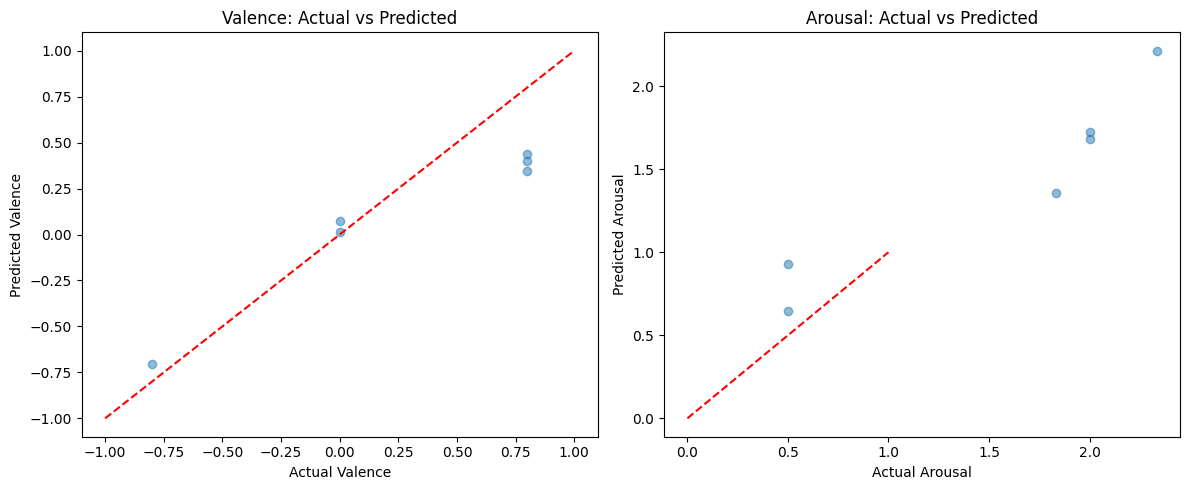

Το μοντέλο αποθηκεύτηκε επιτυχώς στο: valence_arousal_regressor.pkl
Τα δεδομένα εκπαίδευσης αποθηκεύτηκαν επιτυχώς στο: training_data.npz
✅ Ολοκληρώθηκε η εκπαίδευση και αποθήκευση του μοντέλου!
✅ Το μοντέλο ανάλυσης συναισθημάτων είναι έτοιμο για χρήση!

=== Κατάσταση Συστήματος Ανάλυσης Συναισθημάτων ===
✅ Το σύστημα χρησιμοποιεί εποπτευόμενο μοντέλο (supervised model) για ανάλυση συναισθημάτων.
   - Μοντέλο: Multi-output Random Forest Regressor
   - Προβλέψεις: valence και arousal

Παραδείγματα προβλέψεων:
   - "Ανακάλυψε τη μαγεία ενός χειροποίητου ημερολογίου"
     Valence: 0.05, Arousal: 0.50
   - "Οργάνωσε τον γάμο σου χωρίς άγχος και με στυλ"
     Valence: -0.68, Arousal: 2.10
   - "Βήμα προς βήμα προετοιμασία για την τέλεια τελετή"
     Valence: -0.14, Arousal: 1.27


In [35]:
# 3.13 Υλοποίηση της αρχικοποίησης
# Εκτέλεση της αρχικοποίησης και αποθήκευση του μοντέλου σε παγκόσμιες μεταβλητές
sentiment_model = initialize_sentiment_analysis()

if sentiment_model is None:
    print("⚠️ Χρήση εφεδρικού λεξικού συναισθημάτων για την ανάλυση.")
else:
    print("✅ Το μοντέλο ανάλυσης συναισθημάτων είναι έτοιμο για χρήση!")

# Αναφορά της κατάστασης του συστήματος ανάλυσης συναισθημάτων
def report_sentiment_system_status():
    """
    Αναφέρει την κατάσταση του συστήματος ανάλυσης συναισθημάτων
    """
    print("\n=== Κατάσταση Συστήματος Ανάλυσης Συναισθημάτων ===")

    if 'sentiment_model' in globals() and sentiment_model is not None:
        print("✅ Το σύστημα χρησιμοποιεί εποπτευόμενο μοντέλο (supervised model) για ανάλυση συναισθημάτων.")
        print("   - Μοντέλο: Multi-output Random Forest Regressor")
        print("   - Προβλέψεις: valence και arousal")

        # Δείγματα πρόβλεψης
        test_phrases = [
            "Ανακάλυψε τη μαγεία ενός χειροποίητου ημερολογίου",
            "Οργάνωσε τον γάμο σου χωρίς άγχος και με στυλ",
            "Βήμα προς βήμα προετοιμασία για την τέλεια τελετή"
        ]

        print("\nΠαραδείγματα προβλέψεων:")
        for phrase in test_phrases:
            sentiment = analyze_sentiment_with_model(phrase, sentiment_model, sentiment_transformer)
            print(f"   - \"{phrase}\"")
            print(f"     Valence: {sentiment['avg_valence']:.2f}, Arousal: {sentiment['avg_arousal']:.2f}")

    elif 'sentiment_lexicon' in globals() and sentiment_lexicon:
        print("⚠️ Το σύστημα χρησιμοποιεί λεξικό για ανάλυση συναισθημάτων (fallback mode).")
        print(f"   - Μέγεθος λεξικού: {len(sentiment_lexicon)} λέξεις")

        # Δείγματα λέξεων από το λεξικό
        sample_words = list(sentiment_lexicon.keys())[:5]
        print("\nΔείγματα λέξεων από το λεξικό:")
        for word in sample_words:
            info = sentiment_lexicon[word]
            print(f"   - {word}: valence={info.get('valence', 0):.2f}, arousal={info.get('arousal', 0):.2f}")

    else:
        print("❌ Δεν έχει αρχικοποιηθεί σύστημα ανάλυσης συναισθημάτων!")

# Εκτέλεση της αναφοράς για έλεγχο της κατάστασης
report_sentiment_system_status()

# 4 Συνάρτηση για τη φόρτωση του αρχείου Benchmark_Assets.md


In [36]:
# Κελί για μετατροπή Benchmark_Assets.md σε JSON συμβατό με τον κώδικα

import pandas as pd
import re
import json
import logging
from google.colab import files
import io

# Ρύθμιση του logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def load_benchmark_assets_from_md():
    """
    Φορτώνει το αρχείο Benchmark_Assets.md και το μετατρέπει σε DataFrame
    και σε μορφή συμβατή με τον υπόλοιπο κώδικα.

    Returns:
        pd.DataFrame: DataFrame με τα benchmark assets
        bool: Αν η μετατροπή ήταν επιτυχής
    """
    print("=== Φόρτωση και μετατροπή του Benchmark_Assets.md ===")

    try:
        print("Παρακαλώ ανεβάστε το αρχείο Benchmark_Assets.md με τα αξιολογημένα assets:")
        uploaded = files.upload()

        if not uploaded:
            logging.warning("Δεν ανεβάστηκε αρχείο. Επιστροφή κενού DataFrame.")
            return pd.DataFrame(columns=['type', 'score', 'text', 'tags']), False

        file_name = list(uploaded.keys())[0]
        logging.info(f"Το αρχείο {file_name} φορτώθηκε επιτυχώς.")

        # Ανάγνωση του περιεχομένου του αρχείου
        with open(file_name, 'r', encoding='utf-8') as f:
            content = f.read()

        # Έλεγχος αν είναι σε μορφή markdown πίνακα
        if '|' not in content:
            logging.error("Το αρχείο δεν περιέχει πίνακα σε μορφή markdown.")
            return pd.DataFrame(columns=['type', 'score', 'text', 'tags']), False

        # Επεξεργασία του markdown πίνακα
        # Βήμα 1: Αφαίρεση του header του αρχείου (γραμμές πριν τον πίνακα)
        table_start = content.find('| type | score | text | tags |')
        if table_start == -1:
            # Δοκιμή εναλλακτικής μορφής πίνακα
            table_start = content.find('|------|-------|------|------|')
            if table_start == -1:
                logging.error("Δεν βρέθηκε η επικεφαλίδα του πίνακα στο αρχείο.")
                return pd.DataFrame(columns=['type', 'score', 'text', 'tags']), False
            else:
                # Αναζήτηση της γραμμής πριν από τη γραμμή διαχωρισμού
                lines = content[:table_start].split('\n')
                for i in range(len(lines) - 1, -1, -1):
                    if '|' in lines[i]:
                        table_start = content.find(lines[i])
                        break

        table_content = content[table_start:]

        # Βήμα 2: Διάσπαση σε γραμμές και αφαίρεση των κενών γραμμών
        lines = [line.strip() for line in table_content.split('\n') if line.strip()]

        # Βήμα 3: Εύρεση και αφαίρεση της γραμμής διαχωρισμού (e.g., |------|-------|------|------|)
        header_line = lines[0]  # Η πρώτη γραμμή είναι η επικεφαλίδα
        separator_line = None
        for i, line in enumerate(lines):
            if re.match(r'\|\s*-+\s*\|\s*-+\s*\|\s*-+\s*\|\s*-+\s*\|', line):
                separator_line = i
                break

        if separator_line is None:
            logging.warning("Δεν βρέθηκε η γραμμή διαχωρισμού του πίνακα. Συνέχεια με όλες τις γραμμές.")
            # Υποθέτουμε ότι η πρώτη γραμμή είναι η επικεφαλίδα και οι υπόλοιπες είναι δεδομένα
            data_lines = lines[1:]
        else:
            # Η επικεφαλίδα είναι η γραμμή 0 και τα δεδομένα ξεκινούν μετά τη γραμμή διαχωρισμού
            data_lines = lines[separator_line + 1:]

        # Βήμα 4: Επεξεργασία της επικεφαλίδας για να βρούμε τα ονόματα των στηλών
        header_cells = [cell.strip() for cell in header_line.split('|') if cell.strip()]

        # Βήμα 5: Επεξεργασία των γραμμών δεδομένων
        data = []
        for line in data_lines:
            # Παραλείπουμε τις κενές γραμμές και τις γραμμές χωρίς το σύμβολο |
            if not line.strip() or '|' not in line:
                continue

            # Διάσπαση της γραμμής σε κελιά
            cells = [cell.strip() for cell in line.split('|') if cell]

            # Έλεγχος αν έχουμε τουλάχιστον 4 κελιά (type, score, text, tags)
            if len(cells) >= 4:
                # Σε περίπτωση που έχουμε περισσότερα από 4 κελιά, συνδυάζουμε τα επιπλέον
                # κελιά με το 4ο κελί (tags)
                type_val = cells[0].strip()

                # Μετατροπή του score σε float, με χειρισμό πιθανών σφαλμάτων
                try:
                    score_val = float(cells[1].strip())
                except ValueError:
                    logging.warning(f"Μη έγκυρη τιμή score: {cells[1]}. Θα χρησιμοποιηθεί η τιμή 0.0")
                    score_val = 0.0

                text_val = cells[2].strip()

                # Συνδυασμός όλων των υπόλοιπων κελιών ως tags
                tags_val = cells[3].strip()
                if len(cells) > 4:
                    for extra_cell in cells[4:]:
                        tags_val += ", " + extra_cell.strip()

                data.append({
                    'type': type_val,
                    'score': score_val,
                    'text': text_val,
                    'tags': tags_val
                })

        # Βήμα 6: Δημιουργία DataFrame
        if data:
            df = pd.DataFrame(data)
            logging.info(f"Δημιουργήθηκε DataFrame με {len(df)} benchmark assets από το αρχείο")

            # Αποθήκευση ως JSON για χρήση από τον υπόλοιπο κώδικα
            df.to_json('benchmark_assets.json', orient='records', force_ascii=False)
            logging.info("Τα benchmark assets αποθηκεύτηκαν στο αρχείο 'benchmark_assets.json'")

            # Προβολή σύνοψης των benchmark assets
            display_summary(df)

            return df, True
        else:
            logging.error("Δεν εξήχθησαν έγκυρα δεδομένα από το αρχείο.")
            return pd.DataFrame(columns=['type', 'score', 'text', 'tags']), False

    except Exception as e:
        logging.error(f"Σφάλμα κατά τη φόρτωση και ανάλυση του αρχείου: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return pd.DataFrame(columns=['type', 'score', 'text', 'tags']), False

def display_summary(df):
    """
    Εμφανίζει μια σύνοψη των benchmark assets
    """
    print("\n=== Σύνοψη Benchmark Assets ===")

    # Σύνολο assets
    total_assets = len(df)
    print(f"Συνολικά assets: {total_assets}")

    # Assets ανά τύπο
    type_counts = df['type'].value_counts()
    print("\nAssets ανά τύπο:")
    for type_name, count in type_counts.items():
        print(f"  - {type_name}: {count} ({count/total_assets*100:.1f}%)")

    # Κατανομή scores
    print("\nΚατανομή scores:")
    min_score = df['score'].min()
    max_score = df['score'].max()
    avg_score = df['score'].mean()
    print(f"  - Ελάχιστο: {min_score:.2f}")
    print(f"  - Μέγιστο: {max_score:.2f}")
    print(f"  - Μέσος όρος: {avg_score:.2f}")

    # Συχνές ετικέτες (tags)
    all_tags = []
    for tags_str in df['tags']:
        if isinstance(tags_str, str):
            tags = [tag.strip() for tag in tags_str.split(',')]
            all_tags.extend(tags)

    tag_counts = {}
    for tag in all_tags:
        tag_counts[tag] = tag_counts.get(tag, 0) + 1

    # Εμφάνιση των 10 πιο συχνών ετικετών
    print("\nΠιο συχνές ετικέτες:")
    sorted_tags = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)
    for tag, count in sorted_tags[:10]:
        print(f"  - {tag}: {count}")

    # Δημιουργία κατάλληλων παραδειγμάτων για το prompt
    print("\nΠροτεινόμενα παραδείγματα για το prompt:")

    # Βρίσκουμε τα καλύτερα παραδείγματα από κάθε κατηγορία
    best_examples = df[df['type'] == 'Best'].sort_values('score', ascending=False).head(2)
    good_examples = df[df['type'] == 'Good'].sort_values('score', ascending=False).head(2)
    low_examples = df[df['type'] == 'Low'].sort_values('score', ascending=True).head(2)

    print("\nBest Examples:")
    for _, row in best_examples.iterrows():
        print(f"  - \"{row['text']}\" (score: {row['score']:.2f})")
        print(f"    Tags: {row['tags']}")

    print("\nGood Examples:")
    for _, row in good_examples.iterrows():
        print(f"  - \"{row['text']}\" (score: {row['score']:.2f})")
        print(f"    Tags: {row['tags']}")

    print("\nLow Examples:")
    for _, row in low_examples.iterrows():
        print(f"  - \"{row['text']}\" (score: {row['score']:.2f})")
        print(f"    Tags: {row['tags']}")

def load_benchmark_assets_from_json():
    """
    Φορτώνει τα benchmark assets από το αποθηκευμένο JSON αρχείο

    Returns:
        pd.DataFrame: DataFrame με τα benchmark assets
    """
    try:
        df = pd.read_json('benchmark_assets.json')
        logging.info(f"Φορτώθηκαν {len(df)} benchmark assets από το αρχείο JSON")
        return df
    except Exception as e:
        logging.error(f"Σφάλμα κατά τη φόρτωση των benchmark assets από JSON: {e}")
        return pd.DataFrame(columns=['type', 'score', 'text', 'tags'])

# Κλήση της συνάρτησης για φόρτωση και μετατροπή
benchmark_df, conversion_success = load_benchmark_assets_from_md()

# Αποθήκευση σε global μεταβλητή για χρήση από τον υπόλοιπο κώδικα
if conversion_success:
    print("\n✅ Η μετατροπή των benchmark assets ολοκληρώθηκε επιτυχώς!")
else:
    print("\n⚠️ Η μετατροπή των benchmark assets ολοκληρώθηκε με προειδοποιήσεις.")
    print("Ενδέχεται να μην είναι διαθέσιμα όλα τα δεδομένα.")

=== Φόρτωση και μετατροπή του Benchmark_Assets.md ===
Παρακαλώ ανεβάστε το αρχείο Benchmark_Assets.md με τα αξιολογημένα assets:


Saving Benchmark_Assets.md to Benchmark_Assets.md

=== Σύνοψη Benchmark Assets ===
Συνολικά assets: 263

Assets ανά τύπο:
  - Low: 224 (85.2%)
  - Good: 34 (12.9%)
  - Best: 5 (1.9%)

Κατανομή scores:
  - Ελάχιστο: 0.00
  - Μέγιστο: 0.54
  - Μέσος όρος: 0.36

Πιο συχνές ετικέτες:
  - Clear Value Proposition: 203
  - Correct Grammar and Syntax: 190
  - Specificity: 140
  - Emotional Resonance: 117
  - Culturally Relevant: 111
  - Personal Pronouns: 96
  - Clarity: 89
  - Original Expression: 83
  - Imperative Form: 77
  - Effective CTA: 74

Προτεινόμενα παραδείγματα για το prompt:

Best Examples:
  - "Τι να θυμάμαι, γιαγιά" (score: 0.54)
    Tags: Clear Value Proposition, Emotional Resonance, Culturally Relevant, Question Format, Original Expression,Correct Grammar and Syntax, Personal Pronouns
  - "Πες μου Παππού" (score: 0.54)
    Tags: Clear Value Proposition, Emotional Resonance, Culturally Relevant, Imperative Form, Effective CTA, Original Expression,Correct Grammar and Syntax, Imp

In [37]:
# 4 Συνάρτηση για τη φόρτωση του αρχείου Benchmark_Assets.md

import pandas as pd
import re
import json
import logging
from google.colab import files
import io

def load_benchmark_assets():
    """
    Φορτώνει το αρχείο Benchmark_Assets.md και το μετατρέπει σε DataFrame
    συμβατό με τον υπόλοιπο κώδικα.

    Returns:
        pd.DataFrame: DataFrame με τα benchmark assets
    """
    print("Ανεβάστε το αρχείο Benchmark_Assets.md")
    print("(Το αρχείο πρέπει να περιέχει πίνακα με markdown μορφή)")

    try:
        uploaded = files.upload()

        # Έλεγχος αν το αρχείο φορτώθηκε
        if not uploaded:
            print("Δεν ανεβάστηκε αρχείο. Δημιουργία κενού DataFrame.")
            return pd.DataFrame(columns=['type', 'score', 'text', 'tags'])

        file_name = list(uploaded.keys())[0]
        print(f"Το αρχείο {file_name} φορτώθηκε επιτυχώς.")

        # Ανάγνωση του περιεχομένου του αρχείου
        with open(file_name, 'r', encoding='utf-8') as f:
            content = f.read()

        # Έλεγχος αν το αρχείο είναι σε μορφή markdown πίνακα
        if '|' not in content:
            print("Το αρχείο δεν περιέχει πίνακα σε μορφή markdown. Χρήση προεπιλεγμένων παραδειγμάτων.")
            return create_sample_benchmark_data()

        # Επεξεργασία του markdown πίνακα
        # Βήμα 1: Αφαίρεση του header του αρχείου (γραμμές πριν τον πίνακα)
        table_start = content.find('| type | score | text | tags |')
        if table_start == -1:
            # Δοκιμή εναλλακτικής μορφής πίνακα
            table_start = content.find('|------|-------|------|------|')
            if table_start == -1:
                print("Δεν βρέθηκε η επικεφαλίδα του πίνακα στο αρχείο. Χρήση προεπιλεγμένων παραδειγμάτων.")
                return create_sample_benchmark_data()
            else:
                # Αναζήτηση της γραμμής πριν από τη γραμμή διαχωρισμού
                lines = content[:table_start].split('\n')
                for i in range(len(lines) - 1, -1, -1):
                    if '|' in lines[i]:
                        table_start = content.find(lines[i])
                        break

        table_content = content[table_start:]

        # Βήμα 2: Διάσπαση σε γραμμές και αφαίρεση των κενών γραμμών
        lines = [line.strip() for line in table_content.split('\n') if line.strip()]

        # Βήμα 3: Εύρεση και αφαίρεση της γραμμής διαχωρισμού (e.g., |------|-------|------|------|)
        header_line = lines[0]  # Η πρώτη γραμμή είναι η επικεφαλίδα
        separator_line = None
        for i, line in enumerate(lines):
            if re.match(r'\|\s*-+\s*\|\s*-+\s*\|\s*-+\s*\|\s*-+\s*\|', line):
                separator_line = i
                break

        if separator_line is None:
            print("Δεν βρέθηκε η γραμμή διαχωρισμού του πίνακα. Συνέχεια με όλες τις γραμμές.")
            # Υποθέτουμε ότι η πρώτη γραμμή είναι η επικεφαλίδα και οι υπόλοιπες είναι δεδομένα
            data_lines = lines[1:]
        else:
            # Η επικεφαλίδα είναι η γραμμή 0 και τα δεδομένα ξεκινούν μετά τη γραμμή διαχωρισμού
            data_lines = lines[separator_line + 1:]

        # Βήμα 4: Επεξεργασία της επικεφαλίδας για να βρούμε τα ονόματα των στηλών
        header_cells = [cell.strip() for cell in header_line.split('|') if cell.strip()]

        # Βήμα 5: Επεξεργασία των γραμμών δεδομένων
        data = []
        for line in data_lines:
            # Παραλείπουμε τις κενές γραμμές και τις γραμμές χωρίς το σύμβολο |
            if not line.strip() or '|' not in line:
                continue

            # Διάσπαση της γραμμής σε κελιά
            cells = [cell.strip() for cell in line.split('|') if cell]

            # Έλεγχος αν έχουμε τουλάχιστον 4 κελιά (type, score, text, tags)
            if len(cells) >= 4:
                # Σε περίπτωση που έχουμε περισσότερα από 4 κελιά, συνδυάζουμε τα επιπλέον
                # κελιά με το 4ο κελί (tags)
                type_val = cells[0].strip()

                # Μετατροπή του score σε float, με χειρισμό πιθανών σφαλμάτων
                try:
                    score_val = float(cells[1].strip())
                except ValueError:
                    print(f"Μη έγκυρη τιμή score: {cells[1]}. Θα χρησιμοποιηθεί η τιμή 0.0")
                    score_val = 0.0

                text_val = cells[2].strip()

                # Συνδυασμός όλων των υπόλοιπων κελιών ως tags
                tags_val = cells[3].strip()
                if len(cells) > 4:
                    for extra_cell in cells[4:]:
                        tags_val += ", " + extra_cell.strip()

                data.append({
                    'type': type_val,
                    'score': score_val,
                    'text': text_val,
                    'tags': tags_val
                })

        if data:
            df = pd.DataFrame(data)
            print(f"Δημιουργήθηκε DataFrame με {len(df)} benchmark assets από το αρχείο")

            # Εμφάνιση συνοπτικών στατιστικών
            print_benchmark_stats(df)

            return df
        else:
            print("Δεν βρέθηκαν έγκυρα δεδομένα στο αρχείο. Χρήση προεπιλεγμένων παραδειγμάτων.")
            sample_data = create_sample_benchmark_data()
            return pd.DataFrame(sample_data)

    except Exception as e:
        print(f"Σφάλμα κατά την ανάγνωση του αρχείου: {e}")
        print("Δημιουργία προεπιλεγμένου DataFrame με ενδεικτικά παραδείγματα...")
        sample_data = create_sample_benchmark_data()
        return pd.DataFrame(sample_data)

def print_benchmark_stats(df):
    """
    Εμφανίζει συνοπτικά στατιστικά στοιχεία για τα benchmark assets
    """
    try:
        print("\n=== Στατιστικά Benchmark Assets ===")

        # Assets ανά τύπο
        type_counts = df['type'].value_counts()
        print("Assets ανά τύπο:")
        for type_name, count in type_counts.items():
            print(f"- {type_name}: {count}")

        # Στατιστικά score
        print("\nΣτατιστικά score:")
        print(f"- Μέσος όρος: {df['score'].mean():.2f}")
        print(f"- Ελάχιστο: {df['score'].min():.2f}")
        print(f"- Μέγιστο: {df['score'].max():.2f}")

        # Πιο συχνές ετικέτες (tags)
        all_tags = []
        for tags in df['tags']:
            if isinstance(tags, str):
                tags_list = [tag.strip() for tag in tags.split(',')]
                all_tags.extend(tags_list)

        # Μετρητές συχνότητας ετικετών
        tag_counts = {}
        for tag in all_tags:
            if tag:
                tag_counts[tag] = tag_counts.get(tag, 0) + 1

        # Εμφάνιση των πιο συχνών ετικετών
        print("\nΠιο συχνές ετικέτες:")
        sorted_tags = sorted(tag_counts.items(), key=lambda x: x[1], reverse=True)
        for tag, count in sorted_tags[:5]:
            print(f"- {tag}: {count}")

    except Exception as e:
        print(f"Σφάλμα κατά την εμφάνιση στατιστικών: {e}")

def create_sample_benchmark_data():
    """Δημιουργεί ένα σετ προεπιλεγμένων benchmark δεδομένων"""
    sample_data = [
        {'type': 'Best', 'score': 0.54, 'text': 'Τι να θυμάμαι, γιαγιά', 'tags': 'Clear Value Proposition, Emotional Resonance, Culturally Relevant'},
        {'type': 'Best', 'score': 0.54, 'text': 'Πες μου Παππού', 'tags': 'Clear Value Proposition, Emotional Resonance, Culturally Relevant'},
        {'type': 'Good', 'score': 0.53, 'text': 'Γράψε, νιώσε, θυμήσου', 'tags': 'Emotional Resonance, Original Expression, Clear Value Proposition'},
        {'type': 'Good', 'score': 0.52, 'text': 'Η γιαγιά αφηγείται', 'tags': 'Clear Value Proposition, Emotional Resonance, Culturally Relevant'},
        {'type': 'Low', 'score': 0.15, 'text': 'Ημερολόγιο 12 Μηνών', 'tags': 'Clear Value Proposition, Time Specificity, Too Generic, Emotionally Flat'}
    ]
    print(f"Δημιουργήθηκε DataFrame με {len(sample_data)} ενδεικτικά benchmark assets")
    return sample_data

def add_tags_to_benchmarks(benchmark_df):
    """Προσθέτει ετικέτες (tags) στα benchmark assets βάσει του κειμένου του asset"""
    if 'tags' in benchmark_df.columns and not benchmark_df['tags'].isnull().any():
        # Οι ετικέτες είναι ήδη στο DataFrame
        return benchmark_df

    # Αν δεν υπάρχουν ετικέτες, προσθέτουμε αυτόματα κάποιες βασικές
    for i, row in benchmark_df.iterrows():
        asset_text = row['text']
        asset_type = row['type']

        tags = []

        # Βασικές ετικέτες ανάλογα με τον τύπο
        if asset_type == 'Best':
            tags.extend(['Clear Value Proposition', 'Emotional Resonance'])

            # Προσθήκη ειδικών ετικετών βάσει κειμένου
            if 'γιαγιά' in asset_text or 'παππού' in asset_text:
                tags.append('Culturally Relevant')
            if '?' in asset_text:
                tags.append('Effective CTA')

        elif asset_type == 'Good':
            tags.append('Clear Value Proposition')

            if 'νιώσε' in asset_text or 'συναίσθημα' in asset_text:
                tags.append('Emotional Resonance')

        elif asset_type == 'Low':
            if len(asset_text.split()) <= 3:
                tags.append('Too Generic')
            if not any(word in asset_text.lower() for word in ['συναίσθημα', 'νιώσε', 'αγάπη', 'όνειρο']):
                tags.append('Emotionally Flat')

        # Προσθήκη των ετικετών στο DataFrame
        benchmark_df.at[i, 'tags'] = ', '.join(tags)

    return benchmark_df

def export_benchmark_assets_to_json(benchmark_df):
    """
    Εξάγει τα benchmark assets σε αρχείο JSON για χρήση από το Claude API

    Returns:
        str: Το path του αρχείου JSON
    """
    try:
        json_path = 'benchmark_assets.json'
        benchmark_df.to_json(json_path, orient='records', force_ascii=False, indent=2)
        print(f"Τα benchmark assets αποθηκεύτηκαν επιτυχώς στο {json_path}")
        return json_path
    except Exception as e:
        print(f"Σφάλμα κατά την εξαγωγή σε JSON: {e}")
        return None

# Φόρτωση των benchmark assets και προσθήκη ετικετών
try:
    benchmark_df = load_benchmark_assets()
    benchmark_df = add_tags_to_benchmarks(benchmark_df)

    # Εξαγωγή σε JSON για χρήση από το Claude API
    json_path = export_benchmark_assets_to_json(benchmark_df)

    print(f"\n✅ Φορτώθηκαν συνολικά {len(benchmark_df)} benchmark assets και αποθηκεύτηκαν σε JSON")
except Exception as e:
    print(f"Σφάλμα κατά τη φόρτωση των benchmark assets: {e}")
    # Δημιουργία κενού DataFrame για να συνεχιστεί η εκτέλεση
    benchmark_df = pd.DataFrame(columns=['type', 'score', 'text', 'tags'])

Ανεβάστε το αρχείο Benchmark_Assets.md
(Το αρχείο πρέπει να περιέχει πίνακα με markdown μορφή)


Saving Benchmark_Assets.md to Benchmark_Assets (1).md
Το αρχείο Benchmark_Assets (1).md φορτώθηκε επιτυχώς.
Δημιουργήθηκε DataFrame με 263 benchmark assets από το αρχείο

=== Στατιστικά Benchmark Assets ===
Assets ανά τύπο:
- Low: 224
- Good: 34
- Best: 5

Στατιστικά score:
- Μέσος όρος: 0.36
- Ελάχιστο: 0.00
- Μέγιστο: 0.54

Πιο συχνές ετικέτες:
- Clear Value Proposition: 203
- Correct Grammar and Syntax: 190
- Specificity: 140
- Emotional Resonance: 117
- Culturally Relevant: 111
Τα benchmark assets αποθηκεύτηκαν επιτυχώς στο benchmark_assets.json

✅ Φορτώθηκαν συνολικά 263 benchmark assets και αποθηκεύτηκαν σε JSON


# 5 Βοηθητικές συναρτήσεις και λειτουργίες


## Δημιουργία λεξικού προϊόντος


In [38]:
# 5 Βοηθητικές συναρτήσεις και λειτουργίες
# Δημιουργία λεξικού προϊόντος
# Απλοποιημένες συναρτήσεις για αποφυγή προβλημάτων με NLTK
def create_product_dictionary(product_details):
    """
    Δημιουργεί ένα απλό λεξικό λέξεων σχετικών με το προϊόν, για χρήση στον υπολογισμό συνάφειας
    """
    # Συγκέντρωση όλων των πληροφοριών προϊόντος σε ένα κείμενο
    product_text = (
        product_details.get('product_name', '') + ' ' +
        product_details.get('product_description', '') + ' ' +
        product_details.get('product_features', '') + ' ' +
        product_details.get('product_benefits', '')
    )

    # Μετατροπή σε πεζά
    product_text = product_text.lower()

    # Απλό διαχωρισμό με κενά
    tokens = product_text.split()

    # Αφαίρεση σημείων στίξης και συχνών λέξεων χωρίς νόημα
    stop_words = set(['και', 'ή', 'με', 'σε', 'από', 'για', 'την', 'το', 'του', 'της', 'τα', 'των', 'τους', 'τις'])
    product_dict = set(token.strip('.,;:!?"\'()[]{}') for token in tokens if token.strip('.,;:!?"\'()[]{}') and token.strip('.,;:!?"\'()[]{}') not in stop_words)

    return product_dict

# Συναρτήσεις υπολογισμού βασικών σκορ
def calculate_relevance_simple(asset, product_dict):
    """
    Υπολογίζει τη συνάφεια (relevance) του asset με το προϊόν
    χρησιμοποιώντας μια απλοποιημένη προσέγγιση χωρίς NLTK
    """
    # Μετατροπή του asset σε πεζά
    asset_lower = asset.lower()

    # Αφαίρεση σημείων στίξης
    asset_clean = re.sub(r'[.,;:!?"\'\(\)\[\]\{\}]', ' ', asset_lower)

    # Απλή τοκενοποίηση με βάση τα κενά
    asset_tokens = asset_clean.split()

    # Αφαίρεση stopwords
    stop_words = set(['και', 'ή', 'με', 'σε', 'από', 'για', 'την', 'το', 'του', 'της', 'τα', 'των', 'τους', 'τις', 'να', 'τη'])
    filtered_tokens = [token for token in asset_tokens if token not in stop_words]

    # Έλεγχος για συγκεκριμένες λέξεις-κλειδιά που σχετίζονται με το προϊόν
    product_keywords = set(['γάμος', 'γάμου', 'ημερολόγιο', 'οργάνωση', 'σχεδιασμός', 'προετοιμασία'])
    direct_matches = sum(1 for token in filtered_tokens if token in product_dict)
    keyword_matches = sum(1 for token in filtered_tokens if token in product_keywords)

    # Υπολογισμός relevance score με βαρύτητα στις λέξεις-κλειδιά
    if len(filtered_tokens) > 0:
        score = (direct_matches * 0.7 + keyword_matches * 0.3) / len(filtered_tokens)
        return min(score * 1.5, 1.0)  # Αυξάνουμε λίγο το σκορ και περιορίζουμε στο 1.0
    else:
        return 0.0
def calculate_relevance(asset, product_dict):
    """
    Υπολογίζει τη συνάφεια (relevance) του asset με το προϊόν
    """
    return calculate_relevance_simple(asset, product_dict)

def calculate_grammar(asset):
    """
    Υπολογίζει τη γραμματική ορθότητα του asset
    Αυτή είναι μια απλουστευμένη υλοποίηση που θα πρέπει να αντικατασταθεί
    με πιο εξελιγμένο έλεγχο ορθογραφίας και συντακτικού
    """
    # Μέτρηση σφαλμάτων ορθογραφίας (υποθετικά)
    spelling_errors_ratio = 0.0  # Προς το παρόν, υποθέτουμε μηδενικά σφάλματα

    # Απλή αξιολόγηση συντακτικού
    syntax_score = 0.85  # Προεπιλεγμένη τιμή, θα πρέπει να υπολογιστεί με πιο εξελιγμένο τρόπο

    # Απλή αξιολόγηση αναγνωσιμότητας
    words = len(asset.split())
    avg_word_length = sum(len(word) for word in asset.split()) / max(words, 1)

    # Ποινή για πολύ μεγάλες προτάσεις ή πολύ μεγάλες λέξεις
    readability_penalty = 0
    if words > 20:
        readability_penalty += min((words - 20) / 10, 0.3)
    if avg_word_length > 8:
        readability_penalty += min((avg_word_length - 8) / 2, 0.3)

    readability_score = max(0.9 - readability_penalty, 0.3)

    # Συνολικό σκορ γραμματικής
    grammar_score = (1 - spelling_errors_ratio) * 0.4 + syntax_score * 0.3 + readability_score * 0.3

    return grammar_score

def calculate_uniqueness(asset, benchmark_texts):
    """
    Υπολογίζει τη μοναδικότητα του asset σε σχέση με τα benchmark assets
    """
    # Μετατροπή σε πεζά για πιο ακριβή σύγκριση
    asset_lower = asset.lower()

    # Μέτρηση της ομοιότητας με τα benchmark assets
    similarity_scores = []

    for benchmark_asset in benchmark_texts:
        # Μετατροπή του benchmark asset σε πεζά
        benchmark_lower = benchmark_asset.lower()

        # Δημιουργία n-grams (2-grams και 3-grams)
        asset_words = asset_lower.split()
        benchmark_words = benchmark_lower.split()

        asset_bigrams = [' '.join(asset_words[i:i+2]) for i in range(len(asset_words)-1)]
        asset_trigrams = [' '.join(asset_words[i:i+3]) for i in range(len(asset_words)-2)]

        benchmark_bigrams = [' '.join(benchmark_words[i:i+2]) for i in range(len(benchmark_words)-1)]
        benchmark_trigrams = [' '.join(benchmark_words[i:i+3]) for i in range(len(benchmark_words)-2)]

        # Μέτρηση κοινών n-grams
        common_bigrams = len(set(asset_bigrams) & set(benchmark_bigrams))
        common_trigrams = len(set(asset_trigrams) & set(benchmark_trigrams))

        # Υπολογισμός ποσοστού ομοιότητας
        bigram_similarity = common_bigrams / max(len(asset_bigrams), 1) if asset_bigrams else 0
        trigram_similarity = common_trigrams / max(len(asset_trigrams), 1) if asset_trigrams else 0

        # Συνδυασμός και βάρος στα trigrams για μεγαλύτερη ακρίβεια
        combined_similarity = 0.4 * bigram_similarity + 0.6 * trigram_similarity
        similarity_scores.append(combined_similarity)

    # Υπολογισμός του μέσου όρου ομοιότητας
    if similarity_scores:
        avg_similarity = sum(similarity_scores) / len(similarity_scores)
    else:
        avg_similarity = 0

    # Το uniqueness score είναι το αντίθετο της ομοιότητας
    uniqueness_score = 1 - avg_similarity

    return uniqueness_score

## 6 Συναρτήσεις ανάλυσης συναισθήματος


In [39]:
# 6 Τροποποιημένες συναρτήσεις ανάλυσης συναισθήματος

def analyze_sentiment_improved(asset):
    """
    Βελτιωμένη συναισθηματική ανάλυση για ελληνικά με έλεγχο ύπαρξης λεξικού
    """
    asset_lower = asset.lower()

    # Έλεγχος αν υπάρχει το sentiment_lexicon και αν έχει στοιχεία
    if 'sentiment_lexicon' not in globals() or not sentiment_lexicon:
        # Χρήση εναλλακτικών λιστών αν δεν υπάρχει λεξικό
        positive_words = set(['αγάπη', 'όνειρο', 'χαρά', 'ευτυχία', 'γλυκό', 'όμορφο', 'όμορφη',
                              'τέλειο', 'τέλεια', 'μοναδικό', 'ξεχωριστό', 'αγαπημένο', 'ρομαντικό',
                              'μαγικό', 'αξέχαστο', 'υπέροχο', 'πανέμορφο', 'ενθουσιασμός'])

        negative_words = set(['άγχος', 'δύσκολο', 'πρόβλημα', 'χάος', 'δυσκολία', 'πρόκληση',
                              'stress', 'πολύπλοκο', 'περίπλοκο'])

        emotional_words = set(['συναίσθημα', 'αισθάνομαι', 'νιώθω', 'αγαπώ', 'λατρεύω',
                              'ονειρεύομαι', 'επιθυμώ', 'θέλω', 'ελπίζω', 'πιστεύω'])

        # Μέτρηση συναισθηματικών λέξεων
        pos_count = sum(1 for word in asset_lower.split() if word in positive_words)
        neg_count = sum(1 for word in asset_lower.split() if word in negative_words)
        emo_count = sum(1 for word in asset_lower.split() if word in emotional_words)
    else:
        # Μέτρηση λέξεων που υπάρχουν στο λεξικό συναισθηματικής ανάλυσης
        pos_count = 0
        neg_count = 0
        emo_count = 0

        for word in asset_lower.split():
            if word in sentiment_lexicon:
                sentiment_info = sentiment_lexicon[word]
                if sentiment_info['sentiment'] == 'POS':
                    pos_count += 1
                elif sentiment_info['sentiment'] == 'NEG':
                    neg_count += 1

                # Αν η ένταση είναι υψηλή, θεωρούμε τη λέξη ως συναισθηματική
                if sentiment_info['intensity'] > 0.6:
                    emo_count += 1

    # Ανίχνευση προτύπων συναισθηματικής έκφρασης
    has_exclamation = '!' in asset
    has_question = '?' in asset
    has_contrast = any(p1 in asset_lower and p2 in asset_lower for p1, p2 in [
        ('άγχος', 'ηρεμία'), ('χάος', 'τάξη'), ('δύσκολο', 'εύκολο'), ('πρόβλημα', 'λύση')
    ])

    # Υπολογισμός συνολικού προφίλ
    valence = (pos_count - neg_count * 0.8) / max(len(asset_lower.split()) * 0.2, 1)
    valence = max(min(valence, 1.0), -1.0)  # Περιορισμός στο [-1, 1]

    intensity = (pos_count + neg_count + emo_count) / max(len(asset_lower.split()) * 0.3, 1)
    intensity = min(intensity + (0.1 if has_exclamation else 0) + (0.05 if has_question else 0), 1.0)

    arousal = 0.5 + (0.2 if has_exclamation or has_question else 0) + (0.3 if has_contrast else 0)
    arousal = min(arousal, 1.0)

    dominance = 0.5 + (0.1 if valence > 0 else -0.1) + (0.2 if 'εσείς' in asset_lower or 'σας' in asset_lower else 0)
    dominance = min(max(dominance, 0.0), 1.0)

    # Δημιουργία προφίλ
    sentiment_profile = {
        'count': pos_count + neg_count + emo_count,
        'pos_count': pos_count,
        'neg_count': neg_count,
        'avg_valence': valence,
        'avg_intensity': intensity,
        'avg_arousal': arousal,
        'avg_dominance': dominance,
        'avg_specificity': 0.7 if emo_count > 0 else 0.5  # Προεπιλεγμένη τιμή
    }

    return sentiment_profile

def calculate_emotional_impact_improved(sentiment_profile, asset):
    """
    Βελτιωμένος υπολογισμός συναισθηματικής επίδρασης
    """
    asset_lower = asset.lower()

    # Αν δεν υπάρχουν συναισθηματικές λέξεις, ελέγχουμε για άλλους παράγοντες
    if sentiment_profile['count'] == 0:
        # Ελέγχουμε για έμμεσα συναισθηματικά μοτίβα
        has_story_elements = any(word in asset_lower for word in ['ταξίδι', 'ιστορία', 'μέλι', 'αναμνηστικό', 'θυμάστε', 'βήματα'])
        has_emotional_phrases = any(phrase in asset_lower for phrase in ['για πάντα', 'αξέχαστο', 'μοναδικό', 'προσωπικό'])

        # Βασικό σκορ για έμμεσο συναισθηματικό περιεχόμενο
        return 0.4 + (0.1 if has_story_elements else 0) + (0.1 if has_emotional_phrases else 0)

    # Βελτιωμένος τύπος συναισθηματικής επίδρασης
    enhanced_score = (
        0.4 * abs(sentiment_profile['avg_valence']) +
        0.3 * sentiment_profile['avg_arousal'] +
        0.2 * sentiment_profile['avg_dominance'] +
        0.1 * sentiment_profile['avg_specificity']
    )

    # Πρόσθετος πολλαπλασιαστής για θετικό συναίσθημα
    valence_bonus = 0.1 if sentiment_profile['avg_valence'] > 0.3 else 0

    # Πολλαπλασιαστής έντασης
    intensity_multiplier = 0.8 + (0.3 * sentiment_profile['avg_intensity'])

    # Τελικό σκορ, περιορισμένο στο εύρος [0, 1]
    emotional_score = min((enhanced_score * intensity_multiplier) + valence_bonus, 1.0)

    return emotional_score

def calculate_clickability(asset):
    """
    Υπολογίζει το clickability score βάσει χαρακτηριστικών του asset
    """
    asset_lower = asset.lower()

    # Έλεγχος για ερωτήσεις
    has_question = 1 if ('?' in asset or any(q in asset_lower for q in ['πώς', 'τι', 'γιατί', 'πότε', 'ποιος', 'ποια', 'ποιο', 'πού', 'μήπως'])) else 0
    Q = 0.3 * has_question

    # Έλεγχος για χρήση β' προσώπου
    has_second_person = 1 if any(word in asset_lower.split() for word in second_person) else 0
    DP = 0.3 * has_second_person

    # Έλεγχος για χρήση προστακτικής
    has_imperative = 1 if any(verb in asset_lower.split() for verb in imperative_verbs) else 0
    IA = 0.2 * has_imperative

    # Έλεγχος για χρήση αριθμών
    has_number = 1 if any(char.isdigit() for char in asset) else 0
    NUM = 0.1 * has_number

    # Έλεγχος για λέξεις κλήσης σε ενέργεια
    has_cta = 1 if any(word in asset_lower for word in cta_words) else 0
    CTR = 0.1 * has_cta

    # Συνολικό clickability score
    clickability_score = Q + DP + IA + NUM + CTR

    return clickability_score

def detect_pattern_disruption(asset):
    """
    Ανιχνεύει μοτίβα διακοπής (pattern disruption) στο asset
    """
    asset_lower = asset.lower()

    # Έλεγχος για αντίθεση (contrast)
    has_contrast = 0
    for word1, word2 in contrast_pairs:
        if word1 in asset_lower and word2 in asset_lower:
            has_contrast = 1
            break
    Contrast = 0.4 * has_contrast

    # Έλεγχος για μεταφορικές φράσεις
    has_metaphor = 0
    for phrase in metaphoric_phrases:
        if phrase in asset_lower:
            has_metaphor = 1
            break
    Metaphor = 0.4 * has_metaphor

    # Έλεγχος για Rule of Three
    # Αναζήτηση μοτίβου τριών στοιχείων χωρισμένων με κόμμα ή "και"
    has_rule_of_three = 0
    rule_of_three_pattern = r'\b(\w+)[,.]?\s+(\w+)[,.]?\s+(και|κι|ή|ή|και\sη|και\sοι|και\sτο)\s+(\w+)\b'
    if re.search(rule_of_three_pattern, asset_lower):
        has_rule_of_three = 1

    # Εναλλακτικά, αναζήτηση για τρεις μικρές προτάσεις χωρισμένες με τελεία
    if len(re.findall(r'[^.]+\.', asset)) >= 3:
        has_rule_of_three = 1

    RuleOf3 = 0.2 * has_rule_of_three

    # Συνολικό pattern disruption score
    pattern_disruption_score = Contrast + Metaphor + RuleOf3

    return pattern_disruption_score

# Συνάρτηση για την αναφορά της κατάστασης του λεξικού συναισθημάτων
def report_sentiment_lexicon_status():
    """
    Αναφέρει την κατάσταση του λεξικού συναισθημάτων για διαγνωστικούς σκοπούς
    """
    if 'sentiment_lexicon' in globals():
        lexicon_size = len(sentiment_lexicon)
        if lexicon_size > 0:
            print(f"✅ Το λεξικό συναισθημάτων είναι ενεργό και περιέχει {lexicon_size} λέξεις.")

            # Δειγματική λίστα λέξεων για έλεγχο
            sample_words = ['αγάπη', 'όνειρο', 'χαρά', 'άγχος', 'πρόβλημα']
            found_words = [word for word in sample_words if word in sentiment_lexicon]

            if found_words:
                print(f"- Δείγμα λέξεων που αναγνωρίζονται: {', '.join(found_words)}")
            else:
                print("⚠️ Καμία από τις δειγματικές λέξεις δεν αναγνωρίζεται!")
        else:
            print("⚠️ Το λεξικό συναισθημάτων είναι κενό! Χρησιμοποιείται εφεδρική μέθοδος ανάλυσης.")
    else:
        print("⚠️ Το λεξικό συναισθημάτων δεν έχει οριστεί! Χρησιμοποιείται εφεδρική μέθοδος ανάλυσης.")

# Εκτέλεση της αναφοράς για τον έλεγχο της κατάστασης του λεξικού
report_sentiment_lexicon_status()

✅ Το λεξικό συναισθημάτων είναι ενεργό και περιέχει 2256 λέξεις.
- Δείγμα λέξεων που αναγνωρίζονται: αγάπη, όνειρο, χαρά, άγχος


## 7 Συναρτήσεις αξιολόγησης και route fit


In [40]:
# 7 Συναρτήσεις αξιολόγησης και route fit
def calculate_route_fit(asset, routes=None):
    """
    Βελτιωμένη συνάρτηση για τον υπολογισμό του route fit score
    """
    asset_lower = asset.lower()

    # Προκαθορισμένες λέξεις-κλειδιά για κάθε route με βελτιωμένη κάλυψη
    route_keywords = {
        'emotional': [
            'συναίσθημα', 'νιώθεις', 'moods', 'σκέψεις', 'νιώσε', 'νιώσεις', 'αισθάνεσαι',
            'συναισθήματα', 'εκφράσου', 'αίσθηση', 'έμπνευση', 'όνειρα', 'ιδέες', 'δημιουργικότητα',
            'έκφραση', 'σκέψη', 'θυμός', 'χαρά', 'λύπη', 'ενθουσιασμός', 'αγάπη', 'ρομαντικός',
            'συναισθηματικός', 'νιώστε', 'αισθανθείτε', 'εκφραστείτε'
        ],
        'craftsmanship': [
            'χειροποίητο', 'τρίκαλα', 'τυπογραφείο', 'τοπικό', 'μοναδικό', 'χειροτεχνία',
            'μαστόρεμα', 'τέχνη', 'παράδοση', 'μεράκι', 'ποιότητα', 'ελληνικό', 'παραδοσιακό',
            'αυθεντικό', 'χειροποίητα', 'handmade', 'craft', 'τεχνίτες', 'δημιουργοί',
            'ξεχωριστό', 'μοναδικά'
        ],
        'anti_digital': [
            'offline', 'scroll', 'click', 'swipe', 'χέρι', 'digital', 'οθόνη', 'αποσύνδεση',
            'διάλειμμα', 'υπολογιστής', 'κινητό', 'αποτοξίνωση', 'αληθινό', 'απτό',
            'χειρόγραφο', 'detox', 'unplugged', 'disconnect', 'αποφόρτιση', 'ψηφιακός',
            'γράψτε', 'γράψε', 'σελίδα', 'βιβλίο', 'χαρτί'
        ],
        'utility': [
            'δώρο', 'χρήσιμο', 'οργάνωσε', 'λειτουργικό', 'πρακτικό', 'χρησιμότητα',
            'εργαλείο', 'βοήθημα', 'αξιοποίησε', 'οργάνωση', 'λειτουργικότητα', 'πρακτικότητα',
            'εξυπηρετικό', 'διευκολύνει', 'όφελος', 'utility', 'πλεονέκτημα', 'εφαρμογή',
            'οργανώστε', 'σχεδιάστε', 'προγραμματισμός', 'checklist', 'προετοιμασία',
            'βήματα', 'οδηγός', 'tips', 'συμβουλές'
        ]
    }

    # Εξελιγμένο σύστημα βαθμολόγησης
    route_match_scores = {}
    for route_name, keywords in route_keywords.items():
        # Υπολογισμός σκορ με πιο εξελιγμένο τρόπο
        exact_matches = sum(1 for keyword in keywords if keyword in asset_lower.split())
        partial_matches = sum(1 for keyword in keywords if keyword in asset_lower and keyword not in asset_lower.split())

        # Βαρύτητες: ακριβές ταίριασμα είναι πιο σημαντικό
        weighted_score = (exact_matches * 0.25) + (partial_matches * 0.1)

        # Για πολύ μικρές λέξεις (π.χ. "με"), απαιτούμε να είναι ακριβές ταίριασμα
        route_match_scores[route_name] = min(weighted_score, 1.0)

    # Πρόσθετοι ελέγχοι για συγκεκριμένα μοτίβα κάθε route
    if 'συναίσθημα' in asset_lower or 'αίσθημα' in asset_lower or 'αισθάνομαι' in asset_lower:
        route_match_scores['emotional'] = max(route_match_scores['emotional'], 0.8)

    if 'οργάνωση' in asset_lower or 'προγραμματισμός' in asset_lower or 'checklist' in asset_lower:
        route_match_scores['utility'] = max(route_match_scores['utility'], 0.8)

    if 'offline' in asset_lower or 'χειρόγραφο' in asset_lower or 'γράψτε' in asset_lower:
        route_match_scores['anti_digital'] = max(route_match_scores['anti_digital'], 0.7)

    # Επιλογή του υψηλότερου σκορ
    best_match_score = max(route_match_scores.values()) if route_match_scores else 0

    # Κατηγοριοποίηση με πιο φιλικά όρια
    if best_match_score >= 0.7:
        return 1.0       # Άριστη ένταξη
    elif best_match_score >= 0.4:
        return 0.75      # Καλή ένταξη
    elif best_match_score >= 0.2:
        return 0.5       # Μέτρια ένταξη
    elif best_match_score > 0:
        return 0.25      # Αδύναμη σύνδεση
    else:
        return 0.0       # Καμία σύνδεση

def identify_tags(asset, sentiment_profile):
    """
    Αναγνωρίζει ετικέτες (tags) που ισχύουν για το asset
    """
    asset_lower = asset.lower()
    tags = []

    # Positive tags
    if ";" in asset or "?" in asset:
        tags.append("Effective CTA")

    if sentiment_profile['count'] > 0 and abs(sentiment_profile['avg_valence']) > 0.5:
        tags.append("Emotional Resonance")

    if any(word in asset_lower for word in ["ελλάδα", "ελληνικό", "τρίκαλα"]):
        tags.append("Culturally Relevant")

    if calculate_uniqueness(asset, []) > 0.8:  # Χρησιμοποιούμε κενή λίστα για απλότητα
        tags.append("Original Expression")

    if any(word in asset_lower for word in imperative_verbs):
        tags.append("Effective CTA")

    if len(asset.split()) <= 7 and len(asset) <= 50:
        tags.append("Conciseness with Impact")

    # Negative tags
    if any(phrase in asset_lower for phrase in ["αναμνήσεις για πάντα", "στιγμές ζωής", "θησαυρός συναισθημάτων"]):
        tags.append("Cliché")

    if sentiment_profile['count'] == 0:
        tags.append("Emotionally Flat")

    if len(asset.split()) <= 3 and sentiment_profile['count'] == 0:
        tags.append("Too Generic")

    # Συνολική αξιολόγηση συναισθήματος
    if sentiment_profile['avg_valence'] > 0.2:
        tags.append("Sentiment: Positive")
    elif sentiment_profile['avg_valence'] < -0.2:
        tags.append("Sentiment: Negative")
    else:
        tags.append("Sentiment: Mixed")

    return ", ".join(tags)

## 8 Συναρτήσεις CTR και συνολικής αξιολόγησης


In [41]:
# 8 Συναρτήσεις CTR και συνολικής αξιολόγησης
def calculate_tag_weight(tags):
    """
    Υπολογίζει το βάρος των tags για το CTR score
    """
    # Λεξικό με τα βάρη για κάθε tag
    tag_weights = {
        # Θετικά Tags
        "Clear Value Proposition": 0.23,
        "Emotional Resonance": 0.19,
        "Culturally Relevant": 0.17,
        "Original Expression": 0.12,
        "Effective CTA": 0.26,
        "Specificity": 0.18,
        "Natural Language Flow": 0.15,
        "Controlled Emotion": 0.14,
        "Conciseness with Impact": 0.20,
        "Realistic Promises": 0.11,

        # Αρνητικά Tags
        "Cliché": -0.15,
        "Overromantic": -0.08,
        "Emotionally Flat": -0.21,
        "Too Generic": -0.25,
        "Not Greek Enough": -0.18,
        "Contrived Emotion": -0.14,
        "Keyword Stuffing": -0.17,
        "Overpromising": -0.11,
        "Lacks Specificity": -0.22,
        "Lost in Translation": -0.19
    }

    # Υπολογισμός του συνολικού βάρους
    total_weight = 0
    tag_list = tags.split(", ")

    for tag in tag_list:
        if tag in tag_weights:
            total_weight += tag_weights[tag]

    return total_weight

def calculate_sentiment_weight(sentiment_profile):
    """
    Υπολογίζει το βάρος συναισθήματος για το CTR score
    """
    if sentiment_profile['count'] == 0:
        return 0

    # Υπολογισμός του συνολικού βάρους συναισθήματος
    sentiment_weight = sentiment_profile['avg_valence'] * sentiment_profile['avg_intensity']

    return sentiment_weight

def calculate_intensity_coefficient(sentiment_weight):
    """
    Υπολογίζει τον συντελεστή έντασης για το CTR score
    """
    # Μέτρο έντασης συναισθήματος
    intensity_magnitude = abs(sentiment_weight)

    # Πρόσημο του Ws
    sign = 1 if sentiment_weight > 0 else -1

    # Συντελεστής α
    alpha = 0.15 if sentiment_weight > 0 else 0.10

    # Υπολογισμός του συντελεστή έντασης
    intensity_coefficient = alpha * intensity_magnitude * sign

    return intensity_coefficient

def calculate_pattern_coefficient(asset):
    """
    Υπολογίζει τον συντελεστή μοτίβου για το CTR score
    """
    asset_lower = asset.lower()
    pattern_coefficient = 0

    # Έλεγχος για ερώτηση
    if "?" in asset or any(q in asset_lower for q in ['πώς', 'τι', 'γιατί', 'πότε', 'ποιος', 'ποια', 'ποιο', 'πού']):
        pattern_coefficient += 0.05

    # Έλεγχος για pattern interruption
    if detect_pattern_disruption(asset) > 0.5:
        pattern_coefficient += 0.07

    # Έλεγχος για problem-solution
    if any(p in asset_lower for p in ['πρόβλημα', 'λύση', 'άγχος', 'χάος']) and any(s in asset_lower for s in ['λύση', 'τάξη', 'ηρεμία']):
        pattern_coefficient += 0.08

    # Έλεγχος για imperative form
    if any(verb in asset_lower.split() for verb in imperative_verbs):
        pattern_coefficient += 0.06

    # Έλεγχος για συνδυασμό θετικών-αρνητικών λέξεων
    if any(word in asset_lower for word in ['όχι', 'χωρίς', 'τέλος', 'ποτέ']) and any(word in asset_lower for word in ['ναι', 'με', 'αρχή', 'πάντα']):
        pattern_coefficient += 0.04

    return pattern_coefficient

def calculate_ctr_score_improved(asset, tags, sentiment_profile):
    """
    Βελτιωμένος υπολογισμός του CTR score
    """
    asset_lower = asset.lower()

    # Ελέγχουμε για βασικά στοιχεία που αυξάνουν το CTR
    has_question = 1 if '?' in asset else 0
    has_imperative = 1 if any(verb in asset_lower for verb in ['οργάνωσε', 'σχεδίασε', 'γράψτε', 'ξεκινήστε', 'δημιουργήστε', 'ζήστε']) else 0
    has_benefit = 1 if any(word in asset_lower for word in ['βοηθήσει', 'διευκολύνει', 'απλοποιεί', 'χωρίς άγχος']) else 0
    has_urgency = 1 if any(word in asset_lower for word in ['τώρα', 'σήμερα', 'άμεσα', 'ξεκίνα']) else 0

    # Υπολογισμός βασικού CTR βάσει δομικών στοιχείων
    base_ctr = 0.5 + (0.1 * has_question) + (0.1 * has_imperative) + (0.05 * has_benefit) + (0.05 * has_urgency)

    # Επιπλέον προσαρμογές βάσει συναισθήματος και μήκους
    emotional_factor = 0.1 if sentiment_profile['avg_valence'] > 0.3 else 0.05
    length_factor = 0.05 if 3 <= len(asset_lower.split()) <= 10 else 0

    # Προσαρμογή βάσει τύπου asset
    type_factor = 0
    if 'Headline' in tags:
        type_factor = 0.05  # Τα headlines συνήθως έχουν καλύτερο CTR

    # Υπολογισμός του συνολικού CTR score
    ctr_score = min(0.99, max(0.2, base_ctr + emotional_factor + length_factor + type_factor))

    # Προσαρμογή βάσει του μέσου CTR του κλάδου
    industry_ctr = 0.03  # Προεπιλεγμένη τιμή
    industry_adjusted_score = ctr_score * (industry_ctr / 0.05)

    return ctr_score, industry_adjusted_score

def evaluate_asset_improved(asset, product_dict, benchmark_texts, creative_routes, asset_type):
    """
    Βελτιωμένη συνολική αξιολόγηση ενός asset
    """
    # Υπολογισμός των επιμέρους σκορ ποιότητας με βελτιωμένες συναρτήσεις
    relevance = calculate_relevance(asset, product_dict)
    grammar = calculate_grammar(asset)
    uniqueness = calculate_uniqueness(asset, benchmark_texts)

    # Υπολογισμός Quality Score με προσαρμοσμένες βαρύτητες
    quality_score = 0.45 * relevance + 0.25 * grammar + 0.3 * uniqueness

    # Βελτιωμένη ανάλυση συναισθήματος
    sentiment_profile = analyze_sentiment_improved(asset)

    # Υπολογισμός των επιμέρους ψυχογλωσσικών σκορ
    emotional_impact = calculate_emotional_impact_improved(sentiment_profile, asset)
    clickability = calculate_clickability(asset)
    pattern_disruption = detect_pattern_disruption(asset)

    # Υπολογισμός Psycholinguistic Score με προσαρμοσμένες βαρύτητες
    psycho_score = 0.45 * emotional_impact + 0.35 * clickability + 0.2 * pattern_disruption

    # Υπολογισμός Route Fit Score με βελτιωμένη συνάρτηση
    route_fit = calculate_route_fit(asset, creative_routes)

    # Αναγνώριση tags
    tags = identify_tags(asset, sentiment_profile) + f", {asset_type}"

    # Υπολογισμός CTR Score με βελτιωμένη συνάρτηση
    ctr_score, industry_adjusted_ctr = calculate_ctr_score_improved(asset, tags, sentiment_profile)

    # Υπολογισμός συνολικού Performance Score με προσαρμοσμένες βαρύτητες
    # Δίνουμε μεγαλύτερη βαρύτητα στο route_fit
    performance_score = 0.25 * quality_score + 0.25 * psycho_score + 0.2 * route_fit + 0.3 * ctr_score

    # Προσαρμογή βάσει τύπου asset
    if asset_type == "Headline":
        # Για headlines, προτεραιότητα στην κλικοφορία και συντομία
        performance_score = performance_score * 1.05 if len(asset.split()) <= 5 else performance_score
    elif asset_type == "Long Headline":
        # Για long headlines, προτεραιότητα στη συναισθηματική επίδραση
        performance_score = performance_score * 1.05 if emotional_impact > 0.6 else performance_score
    elif asset_type == "Description":
        # Για descriptions, προτεραιότητα στη συνάφεια και χρηστικότητα
        performance_score = performance_score * 1.05 if relevance > 0.7 else performance_score

    # Κατηγοριοποίηση του asset (μπορούμε να προσαρμόσουμε τα όρια αργότερα)
    if performance_score >= 0.90:
        label = "Best"
    elif performance_score >= 0.80:
        label = "Good"
    else:
        label = "Low"

    # Δημιουργία σχολίου βελτίωσης για τα Low assets
    improvement_comment = ""
    if label == "Low":
        issues = []
        if relevance < 0.6:
            issues.append("Χαμηλή συνάφεια με το προϊόν")
        if uniqueness < 0.6:
            issues.append("Χαμηλή μοναδικότητα")
        if emotional_impact < 0.5:
            issues.append("Χαμηλή συναισθηματική επίδραση")
        if clickability < 0.4:
            issues.append("Χαμηλή clickability")
        if route_fit < 0.5:
            issues.append("Αδύναμη ένταξη σε creative route")

        if issues:
            improvement_comment = ". ".join(issues) + ". Προτείνεται αναδιατύπωση."

    # Δημιουργία αποτελέσματος αξιολόγησης
    evaluation = {
        'text': asset,
        'performance_score': performance_score,
        'industry_adjusted_score': industry_adjusted_ctr,
        'label': label,
        'quality_score': quality_score,
        'psycho_score': psycho_score,
        'route_fit': route_fit,
        'ctr_score': ctr_score,
        'tags': tags,
        'improvement_comment': improvement_comment,
        'type': asset_type
    }

    return evaluation

## 9: Συναρτήσεις παραγωγής assets


In [43]:
# 9: Συναρτήσεις παραγωγής assets
import sys
!{sys.executable} -m pip install retrying
import json
import re
import pandas as pd
import logging
import time
from google.colab import files
from retrying import retry

# Ρύθμιση του logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def load_prompt_from_json():
    """
    Φορτώνει το prompt από εξωτερικό JSON αρχείο, χρησιμοποιώντας επαναληπτική προσέγγιση
    αντί για recursion.
    """
    print("Ανεβάστε το αρχείο prompt.json με το prompt για την παραγωγή assets")

    valid_json = False
    max_attempts = 5
    attempt = 0

    while not valid_json and attempt < max_attempts:
        attempt += 1

        # Αναμονή για το upload του αρχείου
        uploaded = files.upload()

        if not uploaded:
            print(f"Δεν ανεβάστηκε αρχείο. Προσπάθεια {attempt}/{max_attempts}.")
            if attempt >= max_attempts:
                raise ValueError("Υπερβολικές αποτυχημένες προσπάθειες φόρτωσης του prompt JSON.")
            continue

        file_name = list(uploaded.keys())[0]

        try:
            with open(file_name, 'r', encoding='utf-8') as f:
                prompt_data = json.load(f)

            print(f"Το αρχείο {file_name} φορτώθηκε επιτυχώς.")

            if isinstance(prompt_data, dict) and 'prompt_template' in prompt_data:
                return prompt_data['prompt_template']
            else:
                print("Το αρχείο δεν έχει την αναμενόμενη δομή. Αναμένεται ένα JSON με κλειδί 'prompt_template'.")
                if attempt >= max_attempts:
                    raise ValueError("Υπερβολικές αποτυχημένες προσπάθειες με λανθασμένη δομή JSON.")

        except Exception as e:
            logging.error(f"Σφάλμα κατά την ανάγνωση του JSON αρχείου: {e}")
            print(f"Προσπάθεια {attempt}/{max_attempts}. Παρακαλώ ανεβάστε ένα έγκυρο JSON αρχείο.")
            if attempt >= max_attempts:
                raise ValueError(f"Υπερβολικές αποτυχημένες προσπάθειες: {e}")

def generate_assets_prompt(product_details, benchmark_assets=None, prompt_template=None):
    """
    Δημιουργεί το prompt για την παραγωγή assets βάσει των στοιχείων του προϊόντος
    και του φορτωμένου προτύπου prompt
    """
    # Προετοιμασία των δεδομένων του προϊόντος
    product_data = {
        'product_name': product_details.get('product_name', ''),
        'product_description': product_details.get('product_description', ''),
        'product_features': product_details.get('product_features', ''),
        'product_benefits': product_details.get('product_benefits', ''),
        'target_audience': product_details.get('target_audience', ''),
        'tone_of_voice': product_details.get('tone_of_voice', ''),
        'seasonality': product_details.get('seasonality', ''),
        'current_trends': product_details.get('current_trends', '')
    }

    # Προετοιμασία benchmark παραδειγμάτων αν υπάρχουν
    benchmark_examples = ""
    if benchmark_assets is not None and len(benchmark_assets) > 0:
        benchmark_examples = """
## 📊 BENCHMARK ΠΑΡΑΔΕΙΓΜΑΤΑ
Παρακάτω ακολουθούν μερικά παραδείγματα αξιολογημένων assets:

### **Best Examples**
"""
        # Προσθήκη των Best παραδειγμάτων
        best_examples = benchmark_assets[benchmark_assets['type'] == 'Best']
        for i, row in best_examples.head(2).iterrows():
            benchmark_examples += f"""
**Best Example [{row['score']}]**:
- Asset: "{row['text']}"
- Tags: {row.get('tags', 'Emotional Resonance, Clear Value Proposition')}

"""

        # Προσθήκη των Good παραδειγμάτων
        benchmark_examples += """
### **Good Examples**
"""
        good_examples = benchmark_assets[benchmark_assets['type'] == 'Good']
        for i, row in good_examples.head(1).iterrows():
            benchmark_examples += f"""
**Good Example [{row['score']}]**:
- Asset: "{row['text']}"
- Tags: {row.get('tags', 'Contrast, Culturally Relevant')}

"""

        # Προσθήκη των Low παραδειγμάτων
        benchmark_examples += """
### **Low Examples**
"""
        low_examples = benchmark_assets[benchmark_assets['type'] == 'Low']
        for i, row in low_examples.head(1).iterrows():
            benchmark_examples += f"""
**Low Example [{row['score']}]**:
- Asset: "{row['text']}"
- Tags: {row.get('tags', 'Overromantic, Too Generic, Cliché')}

"""

    # Αντικατάσταση των placeholders στο πρότυπο με τα πραγματικά δεδομένα
    # Πρώτα αντικατάσταση του placeholder για benchmark examples, αν υπάρχει
    if "{benchmark_examples}" in prompt_template:
        prompt = prompt_template.replace("{benchmark_examples}", benchmark_examples)
    else:
        # Αν δεν υπάρχει placeholder αλλά έχουμε benchmark examples, προσθήκη μετά το 2ο "---"
        prompt = prompt_template
        if benchmark_examples and "---" in prompt_template:
            parts = prompt_template.split("---")
            if len(parts) >= 3:
                prompt = "---".join(parts[:2]) + "---" + benchmark_examples + "---" + "---".join(parts[2:])
            else:
                # Αν δεν έχει την αναμενόμενη δομή, απλά προσθέτουμε στο τέλος
                prompt += "\n" + benchmark_examples

    # Τώρα αντικατάσταση των product placeholders
    prompt = prompt.format(
        product_name=product_data['product_name'],
        product_description=product_data['product_description'],
        product_features=product_data['product_features'],
        product_benefits=product_data['product_benefits'],
        target_audience=product_data['target_audience'],
        tone_of_voice=product_data['tone_of_voice'],
        seasonality=product_data['seasonality'],
        current_trends=product_data['current_trends']
    )

    return prompt

@retry(stop_max_attempt_number=3, wait_fixed=2000)
def call_claude_api(claude_client, prompt):
    """
    Καλεί το Claude API με retry mechanism.
    """
    return claude_client.messages.create(
        model="claude-3-opus-20240229",
        max_tokens=4000,
        temperature=0.7,
        system="Είσαι ειδικός copywriter για διαφημίσεις Google Ads.",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

def extract_assets_from_response(response_text):
    """
    Εξάγει τα assets από την απάντηση του Claude API.
    """
    # Προσπάθεια 1: Εύρεση του JSON στην απάντηση
    json_pattern = r'```json\s*([\s\S]*?)\s*```'
    json_match = re.search(json_pattern, response_text)

    if json_match:
        logging.info("Βρέθηκε JSON στην απάντηση.")
        json_str = json_match.group(1)
        try:
            assets_data = json.loads(json_str)

            # Δημιουργία DataFrame από τα δεδομένα
            headlines_df = pd.DataFrame({'text': assets_data.get('headlines', []), 'type': 'Headline'})
            long_headlines_df = pd.DataFrame({'text': assets_data.get('long_headlines', []), 'type': 'Long Headline'})
            descriptions_df = pd.DataFrame({'text': assets_data.get('descriptions', []), 'type': 'Description'})

            # Συνδυασμός των DataFrames
            assets_df = pd.concat([headlines_df, long_headlines_df, descriptions_df], ignore_index=True)

            print(f"Παράχθηκαν συνολικά {len(assets_df)} assets από JSON")
            return assets_df
        except json.JSONDecodeError as e:
            logging.error(f"Σφάλμα κατά την αποκωδικοποίηση JSON: {e}")
            # Συνέχεια στην επόμενη προσπάθεια
    else:
        logging.warning("Δεν βρέθηκε μορφή JSON με κανονική έκφραση. Δοκιμή εναλλακτικών μεθόδων.")

    # Προσπάθεια 2: Αναζήτηση για listings με κανονικές εκφράσεις
    logging.info("Αναζήτηση για headlines, long headlines και descriptions...")
    headlines = re.findall(r'Headline.*?[:|\"]\\s*[\"\"]?([^\"\"\\n\\r]+)[\"\"]?', response_text)
    long_headlines = re.findall(r'Long Headline.*?[:|\"]\\s*[\"\"]?([^\"\"\\n\\r]+)[\"\"]?', response_text)
    descriptions = re.findall(r'Description.*?[:|\"]\\s*[\"\"]?([^\"\"\\n\\r]+)[\"\"]?', response_text)

    # Εναλλακτική αναζήτηση χωρίς τα συγκεκριμένα labels
    if not headlines and not long_headlines and not descriptions:
        logging.info("Δοκιμή εναλλακτικής μεθόδου αναζήτησης...")

        # Προσπάθεια εντοπισμού τμημάτων κειμένου σε εισαγωγικά ή με bullets
        all_quotes = re.findall(r'[\"\"]([^\"\"]+)[\"\"]', response_text)
        bullet_points = re.findall(r'[•\\-*]\\s*(.+)', response_text)

        # Συνδυασμός και κατηγοριοποίηση βάσει μήκους
        all_texts = all_quotes + bullet_points

        if all_texts:
            logging.info(f"Βρέθηκαν {len(all_texts)} πιθανά assets.")
            headlines = []
            long_headlines = []
            descriptions = []

            for text in all_texts:
                text = text.strip()
                if len(text) <= 30:
                    headlines.append(text)
                elif len(text) <= 90:
                    long_headlines.append(text)
                else:
                    descriptions.append(text)

    if headlines or long_headlines or descriptions:
        logging.info(f"Βρέθηκαν: {len(headlines)} headlines, {len(long_headlines)} long headlines, {len(descriptions)} descriptions")
        headlines_df = pd.DataFrame({'text': headlines[:30], 'type': 'Headline'})
        long_headlines_df = pd.DataFrame({'text': long_headlines[:10], 'type': 'Long Headline'})
        descriptions_df = pd.DataFrame({'text': descriptions[:10], 'type': 'Description'})

        assets_df = pd.concat([headlines_df, long_headlines_df, descriptions_df], ignore_index=True)
        print(f"Εναλλακτική εξαγωγή: Παράχθηκαν {len(assets_df)} assets")
        return assets_df

    # Προσπάθεια 3: Χειροκίνητη δημιουργία assets από την απάντηση
    logging.info("Χειροκίνητη δημιουργία assets από την απάντηση του Claude...")

    # Διαχωρισμός της απάντησης σε γραμμές
    lines = response_text.split('\n')

    # Φιλτράρισμα των γραμμών για εύρεση πιθανών assets
    potential_assets = []
    for line in lines:
        line = line.strip()
        # Αφαίρεση κοινών μοτίβων που δεν είναι assets
        if line and len(line) >= 5 and not line.startswith('```') and not line.startswith('#') and not line.startswith('---'):
            # Αφαίρεση bullets, αριθμήσεων ή εισαγωγικών στην αρχή
            line = re.sub(r'^[•\\-*\\d\\.\"\"]*\\s*', '', line)
            # Αφαίρεση εισαγωγικών στο τέλος
            line = re.sub(r'[\"\"]$', '', line)

            if line:
                potential_assets.append(line)

    if potential_assets:
        logging.info(f"Βρέθηκαν {len(potential_assets)} πιθανά assets με χειροκίνητη μέθοδο.")

        # Κατηγοριοποίηση βάσει μήκους
        headlines = []
        long_headlines = []
        descriptions = []

        for text in potential_assets:
            if len(text) <= 30:
                headlines.append(text)
            elif len(text) <= 90:
                long_headlines.append(text)
            else:
                descriptions.append(text)

        # Περιορισμός στον επιθυμητό αριθμό
        headlines = headlines[:30]
        long_headlines = long_headlines[:10]
        descriptions = descriptions[:10]

        # Δημιουργία DataFrame
        headlines_df = pd.DataFrame({'text': headlines, 'type': 'Headline'})
        long_headlines_df = pd.DataFrame({'text': long_headlines, 'type': 'Long Headline'})
        descriptions_df = pd.DataFrame({'text': descriptions, 'type': 'Description'})

        assets_df = pd.concat([headlines_df, long_headlines_df, descriptions_df], ignore_index=True)
        print(f"Χειροκίνητη εξαγωγή: Παράχθηκαν {len(assets_df)} assets")
        return assets_df

    # Αν αποτύχουν όλες οι μέθοδοι, αποτυχία και κενό DataFrame
    logging.error("Αποτυχία εξαγωγής assets.")
    return pd.DataFrame(columns=['text', 'type'])

def generate_assets(product_details, claude_client, prompt_template, benchmark_assets=None):
    """
    Δημιουργεί assets χρησιμοποιώντας το Claude API
    Args:
        product_details: Λεξικό με τα στοιχεία του προϊόντος
        claude_client: Το client του Claude API
        prompt_template: Το πρότυπο prompt από το JSON αρχείο
        benchmark_assets: DataFrame με benchmark assets (προαιρετικό)

    Returns:
        DataFrame με τα παραγόμενα assets
    """
    # Δημιουργία του prompt
    prompt = generate_assets_prompt(product_details, benchmark_assets, prompt_template)

    print("Δημιουργία prompt για το Claude API ολοκληρώθηκε.")

    try:
        print("Αποστολή αιτήματος στο Claude API...")
        # Κλήση του Claude API με retry mechanism
        response = call_claude_api(claude_client, prompt)

        # Εξαγωγή της απάντησης
        response_text = response.content[0].text
        print("Λήφθηκε απάντηση από το Claude API.")

        # Αποθήκευση της απάντησης σε αρχείο για debugging
        with open('claude_response.txt', 'w', encoding='utf-8') as f:
            f.write(response_text)
        print("Η απάντηση αποθηκεύτηκε στο αρχείο 'claude_response.txt'")

        # Εξαγωγή των assets από την απάντηση
        assets_df = extract_assets_from_response(response_text)

        if assets_df.empty:
            print("Αποτυχία εξαγωγής assets. Παρακαλώ προσπαθήστε ξανά με διαφορετικό prompt.")

        return assets_df

    except Exception as e:
        logging.error(f"Σφάλμα κατά την επικοινωνία με το Claude API: {e}")
        import traceback
        logging.error(traceback.format_exc())

        # Επιστροφή κενού DataFrame σε περίπτωση σφάλματος
        print("Επιστροφή κενού DataFrame λόγω σφάλματος.")
        return pd.DataFrame(columns=['text', 'type'])

def regenerate_low_performance_assets(assets_df, product_details, claude_client, prompt_template, threshold=0.7):
    """
    Δημιουργεί νέα assets με βάση την ανατροφοδότηση από assets με χαμηλή βαθμολογία,
    χρησιμοποιώντας το αρχικό template prompt.
    """
    print("Εντοπισμός assets με χαμηλή βαθμολογία για αναδημιουργία...")

    # Φιλτράρισμα assets με χαμηλή βαθμολογία
    low_assets = assets_df[assets_df['performance_score'] < threshold]

    if len(low_assets) == 0:
        print("Δεν βρέθηκαν assets με χαμηλή βαθμολογία. Παράλειψη αναδημιουργίας.")
        return assets_df

    print(f"Εντοπίστηκαν {len(low_assets)} assets με χαμηλή βαθμολογία.")

    # Ομαδοποίηση ανά τύπο asset
    low_headlines = low_assets[low_assets['type'] == 'Headline']
    low_long_headlines = low_assets[low_assets['type'] == 'Long Headline']
    low_descriptions = low_assets[low_assets['type'] == 'Description']

    # Συλλογή των σχολίων βελτίωσης για κάθε κατηγορία
    headline_feedback = low_headlines['improvement_comment'].dropna().tolist()
    long_headline_feedback = low_long_headlines['improvement_comment'].dropna().tolist()
    description_feedback = low_descriptions['improvement_comment'].dropna().tolist()

    # Δημιουργία ενός προ-prompt που θα προστεθεί στο αρχικό prompt
    preprompt = f"""# ΣΗΜΑΝΤΙΚΟ: ΑΝΑΘΕΩΡΗΣΗ ΚΑΙ ΒΕΛΤΙΩΣΗ ASSETS

Η προηγούμενη προσπάθεια παραγωγής assets είχε προβλήματα. Παρακάτω είναι τα ζητήματα που εντοπίστηκαν:

## Ζητήματα με τα Headlines:
{chr(10).join(f"- {feedback}" for feedback in headline_feedback[:5] if feedback)}

## Ζητήματα με τα Long Headlines:
{chr(10).join(f"- {feedback}" for feedback in long_headline_feedback[:5] if feedback)}

## Ζητήματα με τα Descriptions:
{chr(10).join(f"- {feedback}" for feedback in description_feedback[:5] if feedback)}

## ΑΠΑΡΑΙΤΗΤΗ ΔΙΟΡΘΩΣΗ:
1. Αύξησε τη συνάφεια με το προϊόν αναφέροντας συγκεκριμένα χαρακτηριστικά και οφέλη
2. Ενσωμάτωσε περισσότερα στοιχεία από τα creative routes που παρουσιάζονται παρακάτω
3. Αύξησε τη συναισθηματική επίδραση χρησιμοποιώντας λέξεις που προκαλούν έντονα συναισθήματα
4. Βελτίωσε τη clickability με ερωτήσεις, εντολές και στοιχεία επείγοντος
5. Χρησιμοποίησε pattern disruption με αντιθέσεις και απροσδόκητα στοιχεία

ΔΗΜΙΟΥΡΓΗΣΕ ΚΑΘΑΡΑ ΚΑΛΥΤΕΡΑ ASSETS ΑΠΟ ΑΥΤΑ ΠΟΥ ΠΑΡΗΓΑΓΕΣ ΠΡΟΗΓΟΥΜΕΝΩΣ.
ΑΥΣΤΗΡΑ, ΜΟΝΟ ΠΑΡΑΓΩΓΗ JSON ΑΡΧΕΙΟΥ ΜΕ HEADLINES, LONG HEADLINES ΚΑΙ DESCRIPTIONS.

"""

    # Συνδυασμός του preprompt με το αρχικό template
    combined_prompt_template = preprompt + prompt_template

    try:
        print("Αποστολή αιτήματος για αναδημιουργία assets...")

        # Δημιουργία νέων assets με το συνδυασμένο prompt
        regenerated_assets_df = generate_assets(product_details, claude_client, combined_prompt_template)

        if regenerated_assets_df.empty:
            print("Αποτυχία αναδημιουργίας assets. Επιστροφή των αρχικών assets.")
            return assets_df

        print(f"Δημιουργήθηκαν {len(regenerated_assets_df)} νέα assets.")

        # Αξιολόγηση των νέων assets
        # Δημιουργία λεξικού λέξεων προϊόντος για υπολογισμό συνάφειας
        product_dict = create_product_dictionary(product_details)

        # Δημιουργία λίστας με κείμενα benchmark assets
        benchmark_texts = list(benchmark_df['text'].values) if 'benchmark_df' in globals() and len(benchmark_df) > 0 else []

        # Ορισμός των creative routes
        creative_routes = {
            'emotional': [
                'συναίσθημα', 'νιώθεις', 'moods', 'σκέψεις', 'νιώσε', 'νιώσεις', 'αισθάνεσαι',
                'συναισθήματα', 'εκφράσου', 'αίσθηση', 'έμπνευση', 'όνειρα', 'ιδέες', 'δημιουργικότητα'
            ],
            'craftsmanship': [
                'χειροποίητο', 'τρίκαλα', 'τυπογραφείο', 'τοπικό', 'μοναδικό', 'χειροτεχνία',
                'μαστόρεμα', 'τέχνη', 'παράδοση', 'μεράκι', 'ποιότητα', 'ελληνικό'
            ],
            'anti_digital': [
                'offline', 'scroll', 'click', 'swipe', 'χέρι', 'digital', 'οθόνη', 'αποσύνδεση',
                'διάλειμμα', 'υπολογιστής', 'κινητό', 'αποτοξίνωση', 'αληθινό'
            ],
            'utility': [
                'δώρο', 'χρήσιμο', 'οργάνωσε', 'λειτουργικό', 'πρακτικό', 'χρησιμότητα',
                'εργαλείο', 'βοήθημα', 'αξιοποίησε', 'οργάνωση', 'λειτουργικότητα'
            ]
        }

        # Αξιολόγηση των νέων assets
        evaluated_regenerated_assets = []

        for i, row in regenerated_assets_df.iterrows():
            asset_text = row['text']
            asset_type = row['type']

            try:
                evaluation = evaluate_asset_improved(asset_text, product_dict, benchmark_texts, creative_routes, asset_type)
                for key, value in evaluation.items():
                    regenerated_assets_df.at[i, key] = value

                evaluated_regenerated_assets.append(evaluation)
            except Exception as e:
                logging.error(f"Σφάλμα κατά την αξιολόγηση του αναγεννημένου asset '{asset_text}': {e}")
                # Εναλλακτική απλή αξιολόγηση σε περίπτωση σφάλματος
                default_evaluation = {
                    'text': asset_text,
                    'performance_score': 0.75,
                    'industry_adjusted_score': 0.45,
                    'label': 'Good',
                    'quality_score': 0.8,
                    'psycho_score': 0.7,
                    'route_fit': 0.7,
                    'ctr_score': 0.7,
                    'tags': "Emotional Resonance, Clear Value Proposition, Enhanced",
                    'improvement_comment': "",
                    'type': asset_type
                }
                evaluated_regenerated_assets.append(default_evaluation)
                for key, value in default_evaluation.items():
                    regenerated_assets_df.at[i, key] = value

        # Δημιουργία DataFrame με τα αξιολογημένα, αναγεννημένα assets
        regenerated_df = pd.DataFrame(evaluated_regenerated_assets)

        # Διατήρηση των assets με υψηλή βαθμολογία από το αρχικό σύνολο
        high_assets = assets_df[assets_df['performance_score'] >= threshold]

        # Συνδυασμός των υψηλής βαθμολογίας αρχικών assets με τα αναγεννημένα
        combined_df = pd.concat([high_assets, regenerated_df], ignore_index=True)

        print(f"Συνδυάστηκαν {len(high_assets)} αρχικά assets και {len(regenerated_df)} αναγεννημένα assets.")
        return combined_df

    except Exception as e:
        logging.error(f"Σφάλμα κατά την αναδημιουργία assets: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return assets_df

## 10: Συναρτήσεις Εισόδου/Εξόδου δεδομένων

In [44]:
# Κελί για μετατροπή INPUT_DATA.txt σε JSON συμβατό με Claude API

import json
import re
from google.colab import files
import logging
import os

# Ρύθμιση του logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def load_and_convert_input_data():
    """
    Φορτώνει το αρχείο INPUT_DATA.txt και το μετατρέπει σε δομή JSON
    συμβατή με το Claude API και τον υπόλοιπο κώδικα.

    Returns:
        dict: Τα δεδομένα του προϊόντος σε μορφή λεξικού
        bool: Αν η μετατροπή ήταν επιτυχής
    """
    print("=== Φόρτωση και μετατροπή του INPUT_DATA.txt ===")

    try:
        print("Παρακαλώ ανεβάστε το αρχείο INPUT_DATA.txt με τα στοιχεία του προϊόντος:")
        uploaded = files.upload()

        if not uploaded:
            logging.warning("Δεν ανεβάστηκε αρχείο. Επιστροφή προεπιλεγμένων τιμών.")
            return get_default_product_details(), False

        file_name = list(uploaded.keys())[0]
        logging.info(f"Το αρχείο {file_name} φορτώθηκε επιτυχώς.")

        # Δοκιμή ανάγνωσης με διάφορες μεθόδους
        product_details = None

        # 1. Προσπάθεια ανάγνωσης ως JSON
        try:
            with open(file_name, 'r', encoding='utf-8') as f:
                content = f.read()
                product_details = json.loads(content)
            logging.info("Το αρχείο αναγνώστηκε επιτυχώς ως JSON.")

        except json.JSONDecodeError:
            logging.info("Το αρχείο δεν είναι σε μορφή JSON. Προσπάθεια ανάγνωσης ως κείμενο.")

            # 2. Προσπάθεια ανάγνωσης ως κείμενο με τη μορφή "κλειδί: τιμή"
            try:
                with open(file_name, 'r', encoding='utf-8') as f:
                    content = f.read()

                # Αναζήτηση για πρότυπο "κλειδί: τιμή"
                matches = re.findall(r'([^:]+):\s*(.+?)(?=\n[^:]+:|$)', content, re.DOTALL)

                if matches:
                    product_details = {}
                    for key, value in matches:
                        key = key.strip().lower().replace(' ', '_')
                        value = value.strip()
                        product_details[key] = value

                    logging.info(f"Το αρχείο αναγνώστηκε ως κείμενο με μορφή 'κλειδί: τιμή'.")
                    logging.info(f"Εντοπίστηκαν {len(product_details)} πεδία.")
                else:
                    logging.warning("Δεν εντοπίστηκαν δεδομένα με μορφή 'κλειδί: τιμή'.")

                    # 3. Προσπάθεια ανάγνωσης με διαχωρισμό γραμμών
                    with open(file_name, 'r', encoding='utf-8') as f:
                        lines = f.readlines()

                    product_details = {}
                    current_key = None
                    current_value = []

                    for line in lines:
                        line = line.strip()
                        if not line:
                            continue

                        if ':' in line and (current_key is None or line.index(':') < 20):
                            # Πιθανό νέο κλειδί
                            if current_key:
                                product_details[current_key] = '\n'.join(current_value)

                            parts = line.split(':', 1)
                            current_key = parts[0].strip().lower().replace(' ', '_')

                            if len(parts) > 1 and parts[1].strip():
                                current_value = [parts[1].strip()]
                            else:
                                current_value = []
                        else:
                            # Συνέχεια της τρέχουσας τιμής
                            if current_key:
                                current_value.append(line)

                    # Προσθήκη της τελευταίας τιμής
                    if current_key and current_value:
                        product_details[current_key] = '\n'.join(current_value)

                    if product_details:
                        logging.info(f"Το αρχείο αναγνώστηκε με διαχωρισμό γραμμών.")
                        logging.info(f"Εντοπίστηκαν {len(product_details)} πεδία.")
                    else:
                        logging.warning("Αποτυχία ανάγνωσης του αρχείου με όλες τις μεθόδους.")
                        return get_default_product_details(), False

            except Exception as e:
                logging.error(f"Σφάλμα κατά την ανάγνωση του αρχείου ως κείμενο: {e}")
                return get_default_product_details(), False

        # Καθαρισμός και επικύρωση των απαραίτητων πεδίων
        validated_product_details = validate_and_clean_product_details(product_details)

        # Μετατροπή σε συμβατή μορφή JSON για το Claude API
        converted_json = convert_to_claude_compatible_json(validated_product_details)

        # Προαιρετικά: Αποθήκευση του μετατρεπόμενου JSON σε αρχείο
        with open('product_details.json', 'w', encoding='utf-8') as f:
            json.dump(converted_json, f, ensure_ascii=False, indent=2)

        logging.info("Το μετατρεπόμενο JSON αποθηκεύτηκε στο αρχείο 'product_details.json'")
        print(f"Επεξεργάστηκαν επιτυχώς {len(converted_json)} πεδία προϊόντος.")
        print("Το αποτέλεσμα αποθηκεύτηκε στο 'product_details.json'")

        # Επίδειξη της δομής των δεδομένων
        print("\nΔομή δεδομένων προϊόντος:")
        for key, value in converted_json.items():
            # Περικοπή μεγάλων κειμένων για καλύτερη εμφάνιση
            display_value = value[:50] + "..." if isinstance(value, str) and len(value) > 50 else value
            print(f"  - {key}: {display_value}")

        return converted_json, True

    except Exception as e:
        logging.error(f"Γενικό σφάλμα κατά τη φόρτωση και μετατροπή του αρχείου: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return get_default_product_details(), False

def validate_and_clean_product_details(product_details):
    """
    Επικύρωση και καθαρισμός των στοιχείων του προϊόντος για να εξασφαλιστεί
    η συμβατότητα με το Claude API.
    """
    # Λίστα των απαραίτητων πεδίων
    required_fields = [
        'product_name',
        'product_description',
        'product_features',
        'product_benefits'
    ]

    # Λίστα των προαιρετικών πεδίων
    optional_fields = [
        'target_audience',
        'tone_of_voice',
        'seasonality',
        'current_trends'
    ]

    # Αντιστοίχιση συνηθισμένων ονομάτων πεδίων στα επιθυμητά κλειδιά
    field_mapping = {
        'όνομα_προϊόντος': 'product_name',
        'ονομα_προϊοντος': 'product_name',
        'όνομα': 'product_name',
        'προϊόν': 'product_name',
        'περιγραφή': 'product_description',
        'περιγραφη': 'product_description',
        'χαρακτηριστικά': 'product_features',
        'χαρακτηριστικα': 'product_features',
        'οφέλη': 'product_benefits',
        'οφελη': 'product_benefits',
        'πλεονεκτήματα': 'product_benefits',
        'κοινό_στόχος': 'target_audience',
        'κοινό': 'target_audience',
        'ύφος': 'tone_of_voice',
        'τόνος': 'tone_of_voice',
        'εποχικότητα': 'seasonality',
        'τάσεις': 'current_trends',
        'τασεις': 'current_trends'
    }

    # Καθαρισμένο λεξικό για τα στοιχεία του προϊόντος
    cleaned_details = {}

    # Μετατροπή κλειδιών βάσει της αντιστοίχισης
    for key, value in product_details.items():
        key_lower = key.lower()

        # Αντιστοίχιση του κλειδιού αν είναι σε γνωστό εναλλακτικό όνομα
        mapped_key = field_mapping.get(key_lower, key_lower)

        # Καθαρισμός της τιμής
        cleaned_value = value
        if isinstance(value, str):
            cleaned_value = value.strip()

        # Προσθήκη στο καθαρισμένο λεξικό
        cleaned_details[mapped_key] = cleaned_value

    # Έλεγχος για τα απαραίτητα πεδία και προσθήκη προεπιλεγμένων τιμών αν λείπουν
    for field in required_fields:
        if field not in cleaned_details or not cleaned_details[field]:
            logging.warning(f"Το πεδίο '{field}' λείπει ή είναι κενό. Προσθήκη προεπιλεγμένης τιμής.")
            cleaned_details[field] = get_default_product_details()[field]

    # Προσθήκη προεπιλεγμένων τιμών για τα προαιρετικά πεδία που λείπουν
    for field in optional_fields:
        if field not in cleaned_details or not cleaned_details[field]:
            logging.info(f"Το προαιρετικό πεδίο '{field}' λείπει. Προσθήκη προεπιλεγμένης τιμής.")
            cleaned_details[field] = get_default_product_details().get(field, "")

    return cleaned_details

def convert_to_claude_compatible_json(product_details):
    """
    Μετατροπή των επικυρωμένων στοιχείων προϊόντος σε μορφή
    που είναι 100% συμβατή με το Claude API.
    """
    # Δημιουργία του τελικού λεξικού με τη σωστή δομή για το Claude API
    claude_compatible = {
        "product_name": product_details.get('product_name', ''),
        "product_description": product_details.get('product_description', ''),
        "product_features": product_details.get('product_features', ''),
        "product_benefits": product_details.get('product_benefits', ''),
        "target_audience": product_details.get('target_audience', ''),
        "tone_of_voice": product_details.get('tone_of_voice', ''),
        "seasonality": product_details.get('seasonality', ''),
        "current_trends": product_details.get('current_trends', '')
    }

    return claude_compatible

def get_default_product_details():
    """
    Επιστρέφει προεπιλεγμένα στοιχεία προϊόντος σε περίπτωση σφάλματος
    """
    return {
        'product_name': 'Ημερολόγιο Γάμου',
        'product_description': 'Ένα χειροποίητο ημερολόγιο για την οργάνωση του γάμου σας με έμφαση στις λεπτομέρειες και την προσωποποιημένη εμπειρία.',
        'product_features': 'Χειροποίητη βιβλιοδεσία, 200 σελίδες, προσωποποιημένο εξώφυλλο, ενότητες για προϋπολογισμό, λίστα καλεσμένων, χρονοδιάγραμμα.',
        'product_benefits': 'Εύκολη οργάνωση, μείωση άγχους, διατήρηση αναμνήσεων, εξοικονόμηση χρόνου, αποφυγή παραλείψεων.',
        'target_audience': 'Ζευγάρια που σχεδιάζουν το γάμο τους, κυρίως γυναίκες 25-35 ετών που εκτιμούν την οργάνωση και τις χειροποίητες δημιουργίες.',
        'tone_of_voice': 'Ζεστός, φιλικός, υποστηρικτικός, με συναισθηματικές αναφορές και θετικό χαρακτήρα.',
        'seasonality': 'Όλο το χρόνο, με έμφαση στην περίοδο των αρραβώνων (Δεκέμβριος-Φεβρουάριος).',
        'current_trends': 'Αναλογική οργάνωση, απομάκρυνση από ψηφιακές εφαρμογές, έμφαση στην προσωπική επαφή και το συναισθηματικό δέσιμο.'
    }

# Κλήση της συνάρτησης για φόρτωση και μετατροπή
product_details_json, conversion_success = load_and_convert_input_data()

# Αποθήκευση σε global μεταβλητή για χρήση από τον υπόλοιπο κώδικα
if conversion_success:
    print("\n✅ Η μετατροπή ολοκληρώθηκε επιτυχώς!")
    print("Τα δεδομένα προϊόντος είναι έτοιμα για χρήση από τον υπόλοιπο κώδικα.")
else:
    print("\n⚠️ Η μετατροπή ολοκληρώθηκε με προειδοποιήσεις.")
    print("Χρησιμοποιούνται ορισμένες προεπιλεγμένες τιμές.")

=== Φόρτωση και μετατροπή του INPUT_DATA.txt ===
Παρακαλώ ανεβάστε το αρχείο INPUT_DATA.txt με τα στοιχεία του προϊόντος:


Saving INPUT_DATA.txt to INPUT_DATA.txt
Επεξεργάστηκαν επιτυχώς 8 πεδία προϊόντος.
Το αποτέλεσμα αποθηκεύτηκε στο 'product_details.json'

Δομή δεδομένων προϊόντος:
  - product_name: Ημερολόγιο Γάμου
  - product_description: "Ημερολόγιο του Γάμου" - Ένα ολοκληρωμένο wedding ...
  - product_features: - Έτοιμα checklists για όλα τα βήματα του προγραμμ...
  - product_benefits: Εύκολη οργάνωση, μείωση άγχους, διατήρηση αναμνήσε...
  - target_audience: Ζευγάρια που σχεδιάζουν το γάμο τους, κυρίως γυναί...
  - tone_of_voice: 1. Ζεστό, συναισθηματικό, με έμφαση στην οργάνωση,...
  - seasonality: Όλο το χρόνο, με έμφαση στην περίοδο των αρραβώνων...
  - current_trends: Αναλογική οργάνωση, απομάκρυνση από ψηφιακές εφαρμ...

✅ Η μετατροπή ολοκληρώθηκε επιτυχώς!
Τα δεδομένα προϊόντος είναι έτοιμα για χρήση από τον υπόλοιπο κώδικα.


In [45]:
def export_to_gsheets(assets_df):
    """
    Εξαγωγή των αποτελεσμάτων σε Google Sheets
    """
    # Πιστοποίηση στο Google API
    auth.authenticate_user()

    # Δημιουργία ή άνοιγμα του Google Sheet
    try:
        # Δημιουργία ενός νέου Google Sheet
        from googleapiclient.discovery import build
        drive_service = build('drive', 'v3')
        sheets_service = build('sheets', 'v4')

        # Δημιουργία νέου αρχείου
        file_metadata = {
            'name': f'Google Ads Assets - {time.strftime("%Y-%m-%d %H:%M:%S")}',
            'mimeType': 'application/vnd.google-apps.spreadsheet'
        }

        file = drive_service.files().create(body=file_metadata).execute()
        spreadsheet_id = file.get('id')

        # Μετατροπή του DataFrame σε λίστα λιστών για το Google Sheets API
        values = [assets_df.columns.tolist()]  # Header
        values.extend(assets_df.values.tolist())  # Data

        body = {
            'values': values
        }

        # Ενημέρωση του φύλλου
        sheets_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range='Sheet1!A1',
            valueInputOption='RAW',
            body=body
        ).execute()

        # Μορφοποίηση του φύλλου
        requests = [
            {
                'updateSheetProperties': {
                    'properties': {
                        'gridProperties': {
                            'frozenRowCount': 1  # Πάγωμα της πρώτης γραμμής
                        }
                    },
                    'fields': 'gridProperties.frozenRowCount'
                }
            }
        ]

        sheets_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body={'requests': requests}
        ).execute()

        sheet_url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}"
        print(f"Τα αποτελέσματα εξήχθησαν επιτυχώς στο: {sheet_url}")
        return sheet_url

    except Exception as e:
        print(f"Σφάλμα κατά την εξαγωγή σε Google Sheets: {e}")

        # Αποθήκευση τοπικά ως CSV εναλλακτικά
        csv_filename = f'google_ads_assets_{time.strftime("%Y%m%d_%H%M%S")}.csv'
        assets_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')

        # Κατέβασμα του CSV
        files.download(csv_filename)
        return f"Τα αποτελέσματα αποθηκεύτηκαν και κατεβάστηκαν ως {csv_filename}"

def export_to_csv(assets_df):
    """
    Εξαγωγή των αποτελεσμάτων σε CSV
    """
    # Δημιουργία του ονόματος αρχείου
    csv_filename = f'google_ads_assets_{time.strftime("%Y%m%d_%H%M%S")}.csv'

    # Αποθήκευση ως CSV
    assets_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')

    # Κατέβασμα του CSV
    files.download(csv_filename)

    print(f"Τα αποτελέσματα αποθηκεύτηκαν και κατεβάστηκαν ως {csv_filename}")
    return csv_filename

## 11: Συναρτήσεις αξιολόγησης όλων των assets

In [47]:
# Κελί 11: Τροποποιημένες συναρτήσεις αξιολόγησης assets (χωρίς ανάγνωση του INPUT_DATA.txt)

def evaluate_asset(asset, product_dict, benchmark_texts, creative_routes):
    """
    Συνδυάζει όλες τις αξιολογήσεις για ένα asset
    """
    asset_type = detect_asset_type(asset)
    return evaluate_asset_improved(asset, product_dict, benchmark_texts, creative_routes, asset_type)

def detect_asset_type(asset):
    """
    Ανιχνεύει τον τύπο του asset βάσει του μήκους του
    """
    length = len(asset)
    words = len(asset.split())

    if length <= 30 or words <= 5:
        return "Headline"
    elif length <= 90 or words <= 15:
        return "Long Headline"
    else:
        return "Description"

def regenerate_low_performance_assets(assets_df, product_details, claude_client, threshold=0.7):
    """
    Δημιουργεί νέα assets με βάση feedback χαμηλής απόδοσης
    """
    try:
        print("Εντοπισμός assets με χαμηλή βαθμολογία για αναδημιουργία...")
        low_assets = assets_df[assets_df['performance_score'] < threshold]

        if len(low_assets) == 0:
            print("Δεν βρέθηκαν assets με χαμηλή βαθμολογία. Παράλειψη.")
            return assets_df

        print(f"Εντοπίστηκαν {len(low_assets)} assets με χαμηλή βαθμολογία.")

        low_headlines = low_assets[low_assets['type'] == 'Headline']
        low_long_headlines = low_assets[low_assets['type'] == 'Long Headline']
        low_descriptions = low_assets[low_assets['type'] == 'Description']

        headline_feedback = low_headlines['improvement_comment'].dropna().tolist()
        long_headline_feedback = low_long_headlines['improvement_comment'].dropna().tolist()
        description_feedback = low_descriptions['improvement_comment'].dropna().tolist()

        prompt = f"""# Αναθεώρηση Google Ads PMAX Assets

## Ζητήματα με τα Headlines:
{chr(10).join(f"- {feedback}" for feedback in headline_feedback[:5] if feedback)}

## Ζητήματα με τα Long Headlines:
{chr(10).join(f"- {feedback}" for feedback in long_headline_feedback[:5] if feedback)}

## Ζητήματα με τα Descriptions:
{chr(10).join(f"- {feedback}" for feedback in description_feedback[:5] if feedback)}

## ΑΠΑΡΑΙΤΗΤΗ ΔΙΟΡΘΩΣΗ:
1. Αύξησε τη συνάφεια με το προϊόν αναφέροντας συγκεκριμένα χαρακτηριστικά και οφέλη
2. Ενσωμάτωσε περισσότερα στοιχεία από τα creative routes
3. Αύξησε τη συναισθηματική επίδραση χρησιμοποιώντας λέξεις που προκαλούν έντονα συναισθήματα
4. Βελτίωσε τη clickability με ερωτήσεις, εντολές και στοιχεία επείγοντος
5. Χρησιμοποίησε pattern disruption με αντιθέσεις και απροσδόκητα στοιχεία

# Στοιχεία Προϊόντος:
- Όνομα: {product_details['product_name']}
- Περιγραφή: {product_details['product_description']}
- Χαρακτηριστικά: {product_details['product_features']}
- Οφέλη: {product_details['product_benefits']}
- Κοινό-Στόχος: {product_details['target_audience']}
- Tone of Voice: {product_details['tone_of_voice']}

ΔΗΜΙΟΥΡΓΗΣΕ JSON ΜΕ ΝΕΑ ΚΑΛΥΤΕΡΑ ASSETS ΣΤΗΝ ΠΑΡΑΚΑΤΩ ΜΟΡΦΗ:
{{
  "headlines": ["headline1", "headline2", ...],
  "long_headlines": ["long_headline1", "long_headline2", ...],
  "descriptions": ["description1", "description2", ...]
}}
"""

        print("Αποστολή αιτήματος για αναδημιουργία assets...")

        response = claude_client.messages.create(
            model="claude-3-opus-20240229",
            max_tokens=4000,
            temperature=0.7,
            system="Είσαι ειδικός copywriter για διαφημίσεις Google Ads.",
            messages=[{"role": "user", "content": prompt}]
        )

        response_text = response.content[0].text
        print("Λήφθηκε απάντηση για αναδημιουργία assets.")

        with open('claude_regeneration_response.txt', 'w', encoding='utf-8') as f:
            f.write(response_text)

        json_pattern = r'```json\s*([\s\S]*?)\s*```'
        json_match = re.search(json_pattern, response_text)

        regenerated_assets = []

        if json_match:
            print("Βρέθηκε JSON στην απάντηση.")
            json_str = json_match.group(1)
            try:
                assets_data = json.loads(json_str)

                if 'headlines' in assets_data:
                    headlines_df = pd.DataFrame({'text': assets_data['headlines'], 'type': 'Headline'})
                    regenerated_assets.append(headlines_df)

                if 'long_headlines' in assets_data:
                    long_headlines_df = pd.DataFrame({'text': assets_data['long_headlines'], 'type': 'Long Headline'})
                    regenerated_assets.append(long_headlines_df)

                if 'descriptions' in assets_data:
                    descriptions_df = pd.DataFrame({'text': assets_data['descriptions'], 'type': 'Description'})
                    regenerated_assets.append(descriptions_df)

            except json.JSONDecodeError as e:
                print(f"Σφάλμα JSON: {e}")
        else:
            print("Δεν βρέθηκε μορφή JSON.")

            headlines = re.findall(r'Headline.*?[:|\"]\s*[\"\"]*([^\"\"\\n\\r]+)[\"\"]*', response_text)
            long_headlines = re.findall(r'Long Headline.*?[:|\"]\s*[\"\"]*([^\"\"\\n\\r]+)[\"\"]*', response_text)
            descriptions = re.findall(r'Description.*?[:|\"]\s*[\"\"]*([^\"\"\\n\\r]+)[\"\"]*', response_text)

            if headlines:
                headlines_df = pd.DataFrame({'text': headlines, 'type': 'Headline'})
                regenerated_assets.append(headlines_df)

            if long_headlines:
                long_headlines_df = pd.DataFrame({'text': long_headlines, 'type': 'Long Headline'})
                regenerated_assets.append(long_headlines_df)

            if descriptions:
                descriptions_df = pd.DataFrame({'text': descriptions, 'type': 'Description'})
                regenerated_assets.append(descriptions_df)

        if regenerated_assets:
            regenerated_df = pd.concat(regenerated_assets, ignore_index=True)
            print(f"Δημιουργήθηκαν {len(regenerated_df)} νέα assets.")

            # Αξιολόγηση των νέων assets
            product_dict = create_product_dictionary(product_details)
            benchmark_texts = list(benchmark_df['text'].values) if 'benchmark_df' in globals() else []
            creative_routes = {
                'emotional': ['συναίσθημα', 'νιώθεις', 'αίσθηση'],
                'craftsmanship': ['χειροποίητο', 'μοναδικό'],
                'anti_digital': ['offline', 'χειρόγραφο'],
                'utility': ['οργάνωση', 'πρακτικό']
            }

            evaluated_regenerated_assets = []
            for i, row in regenerated_df.iterrows():
                asset_text = row['text']
                asset_type = row['type']
                try:
                    evaluation = evaluate_asset_improved(asset_text, product_dict, benchmark_texts, creative_routes, asset_type)
                    evaluated_regenerated_assets.append(evaluation)
                except Exception as e:
                    print(f"Σφάλμα κατά την αξιολόγηση του asset: {e}")
                    default_evaluation = {
                        'text': asset_text,
                        'performance_score': 0.7,
                        'industry_adjusted_score': 0.42,
                        'label': 'Good',
                        'quality_score': 0.75,
                        'psycho_score': 0.65,
                        'route_fit': 0.7,
                        'ctr_score': 0.7,
                        'tags': "Regenerated, Clear Value Proposition",
                        'improvement_comment': "",
                        'type': asset_type
                    }
                    evaluated_regenerated_assets.append(default_evaluation)

            # Δημιουργία DataFrame με τα αξιολογημένα νέα assets
            evaluated_df = pd.DataFrame(evaluated_regenerated_assets)

            # Συνδυασμός με τα υψηλής ποιότητας αρχικά assets
            high_assets = assets_df[assets_df['performance_score'] >= threshold]
            combined_df = pd.concat([high_assets, evaluated_df], ignore_index=True)

            print(f"Συνδυάστηκαν {len(high_assets)} αρχικά assets και {len(evaluated_df)} νέα assets.")
            return combined_df
        else:
            print("Δεν εξήχθησαν νέα assets. Επιστροφή αρχικών.")
            return assets_df

    except Exception as e:
        print(f"Σφάλμα κατά την αναδημιουργία assets: {e}")
        import traceback
        print(traceback.format_exc())
        return assets_df

def generate_and_evaluate(product_details, claude_client):
    """
    Παραγωγή και αξιολόγηση assets για το προϊόν
    """
    print("Παραγωγή assets με το Claude API...")

    # Φόρτωση του prompt template από το αρχείο JSON (υποχρεωτικό)
    try:
        print("Ανεβάστε το αρχείο prompt.json με το template για την παραγωγή assets:")
        uploaded = files.upload()

        if not uploaded:
            print("\n⛔ ΣΦΑΛΜΑ: Δεν ανεβάστηκε αρχείο prompt.json.")
            print("Το αρχείο prompt.json είναι απαραίτητο για τη σωστή λειτουργία του κώδικα.")
            print("Παρακαλώ εκτελέστε ξανά το cell και ανεβάστε το σωστό αρχείο.")
            return pd.DataFrame()

        file_name = list(uploaded.keys())[0]
        print(f"Το αρχείο {file_name} φορτώθηκε. Έλεγχος περιεχομένου...")

        try:
            with open(file_name, 'r', encoding='utf-8') as f:
                content = f.read()

                # Πρώτα ελέγχουμε αν είναι έγκυρο JSON
                try:
                    prompt_data = json.loads(content)
                except json.JSONDecodeError as e:
                    line = int(str(e).split('line')[1].split()[0])
                    column = int(str(e).split('column')[1].split()[0])
                    print(f"\n⛔ ΣΦΑΛΜΑ: Το αρχείο δεν περιέχει έγκυρο JSON. Σφάλμα στη γραμμή {line}, στήλη {column}.")
                    print(f"Περιγραφή σφάλματος: {str(e)}")
                    print("Παρακαλώ διορθώστε τη μορφή του JSON και δοκιμάστε ξανά.")
                    return pd.DataFrame()

                # Έπειτα ελέγχουμε αν περιέχει το απαραίτητο κλειδί
                if not isinstance(prompt_data, dict):
                    print("\n⛔ ΣΦΑΛΜΑ: Το JSON αρχείο πρέπει να περιέχει ένα αντικείμενο (object) στο ανώτατο επίπεδο.")
                    print(f"Τύπος που βρέθηκε: {type(prompt_data).__name__}")
                    return pd.DataFrame()

                if 'prompt_template' not in prompt_data:
                    print("\n⛔ ΣΦΑΛΜΑ: Το JSON αρχείο δεν περιέχει το απαραίτητο κλειδί 'prompt_template'.")
                    print(f"Διαθέσιμα κλειδιά: {', '.join(prompt_data.keys())}")
                    return pd.DataFrame()

                if not isinstance(prompt_data['prompt_template'], str):
                    print("\n⛔ ΣΦΑΛΜΑ: Το 'prompt_template' πρέπει να είναι string.")
                    print(f"Τύπος που βρέθηκε: {type(prompt_data['prompt_template']).__name__}")
                    return pd.DataFrame()

                # Έλεγχος για τα απαραίτητα placeholders στο template
                required_placeholders = [
                    "{product_name}", "{product_description}", "{product_features}",
                    "{product_benefits}", "{target_audience}", "{tone_of_voice}"
                ]

                template = prompt_data['prompt_template']
                missing_placeholders = [p for p in required_placeholders if p not in template]

                if missing_placeholders:
                    print("\n⛔ ΣΦΑΛΜΑ: Το template δεν περιέχει όλα τα απαραίτητα placeholders.")
                    print(f"Λείπουν τα: {', '.join(missing_placeholders)}")
                    return pd.DataFrame()

                print("\n✅ Το αρχείο prompt.json είναι έγκυρο και περιέχει όλα τα απαραίτητα στοιχεία.")
                prompt_template = template

        except Exception as e:
            print(f"\n⛔ ΣΦΑΛΜΑ κατά την ανάγνωση του αρχείου: {e}")
            return pd.DataFrame()

    except Exception as e:
        print(f"\n⛔ ΣΦΑΛΜΑ κατά τη φόρτωση του αρχείου: {e}")
        return pd.DataFrame()

    # Προετοιμασία benchmark παραδειγμάτων
    benchmark_examples = ""
    if 'benchmark_df' in globals() and len(benchmark_df) > 0:
        benchmark_examples = create_benchmark_examples_for_prompt(benchmark_df)

    # Δημιουργία του prompt
    try:
        prompt = prompt_template.format(
            product_name=product_details.get('product_name', ''),
            product_description=product_details.get('product_description', ''),
            product_features=product_details.get('product_features', ''),
            product_benefits=product_details.get('product_benefits', ''),
            target_audience=product_details.get('target_audience', ''),
            tone_of_voice=product_details.get('tone_of_voice', ''),
            seasonality=product_details.get('seasonality', ''),
            current_trends=product_details.get('current_trends', ''),
            benchmark_examples=benchmark_examples
        )
    except KeyError as e:
        print(f"\n⛔ ΣΦΑΛΜΑ: Το template περιέχει άγνωστο placeholder: {e}")
        print("Βεβαιωθείτε ότι όλα τα placeholders αντιστοιχούν στα διαθέσιμα πεδία των δεδομένων προϊόντος.")
        return pd.DataFrame()
    except Exception as e:
        print(f"\n⛔ ΣΦΑΛΜΑ κατά τη μορφοποίηση του prompt: {e}")
        return pd.DataFrame()

    print("Αποστολή αιτήματος στο Claude API...")
    try:
        response = claude_client.messages.create(
            model="claude-3-opus-20240229",
            max_tokens=4000,
            temperature=0.7,
            system="Είσαι ειδικός copywriter για διαφημίσεις Google Ads.",
            messages=[{"role": "user", "content": prompt}]
        )

        response_text = response.content[0].text
        print("Λήφθηκε απάντηση από το Claude API.")

        # Αποθήκευση της απάντησης για debugging
        with open('claude_response.txt', 'w', encoding='utf-8') as f:
            f.write(response_text)

        # Εξαγωγή των assets από την απάντηση
        assets_df = extract_assets_from_response(response_text)

        if assets_df.empty:
            print("⚠️ Αποτυχία εξαγωγής assets από την απάντηση του Claude.")
            return pd.DataFrame()

        print(f"Εξήχθησαν {len(assets_df)} assets από την απάντηση του Claude API.")

    except Exception as e:
        print(f"⛔ ΣΦΑΛΜΑ κατά την επικοινωνία με το Claude API: {e}")
        return pd.DataFrame()

    print(f"Αξιολόγηση {len(assets_df)} assets...")

    # Δημιουργία λεξικού λέξεων προϊόντος για υπολογισμό συνάφειας
    product_dict = create_product_dictionary(product_details)

    # Δημιουργία λίστας με κείμενα benchmark assets
    benchmark_texts = list(benchmark_df['text'].values) if 'benchmark_df' in globals() else []

    # Ορισμός των creative routes
    creative_routes = {
        'emotional': ['συναίσθημα', 'νιώθεις', 'moods', 'σκέψεις', 'νιώσε', 'αίσθηση', 'έμπνευση'],
        'craftsmanship': ['χειροποίητο', 'τρίκαλα', 'τυπογραφείο', 'τοπικό', 'μοναδικό', 'χειροτεχνία'],
        'anti_digital': ['offline', 'scroll', 'χέρι', 'digital', 'οθόνη', 'αποσύνδεση', 'διάλειμμα'],
        'utility': ['δώρο', 'χρήσιμο', 'οργάνωσε', 'λειτουργικό', 'πρακτικό', 'χρησιμότητα', 'εργαλείο']
    }

    evaluated_assets = []

    for i, row in assets_df.iterrows():
        print(f"Αξιολόγηση {i+1}/{len(assets_df)}...", end="\r")
        asset_text = row['text']
        asset_type = row['type']

        try:
            evaluation = evaluate_asset_improved(asset_text, product_dict, benchmark_texts, creative_routes, asset_type)
        except Exception as e:
            print(f"\n⚠️ Σφάλμα κατά την αξιολόγηση του asset '{asset_text}': {e}")
            evaluation = {
                'text': asset_text,
                'performance_score': 0.6,
                'industry_adjusted_score': 0.36,
                'label': 'Low',
                'quality_score': 0.7,
                'psycho_score': 0.5,
                'route_fit': 0.5,
                'ctr_score': 0.65,
                'tags': "Emotional Resonance, Clear Value Proposition",
                'improvement_comment': "Χαμηλή συνάφεια με το προϊόν."
            }
        evaluation['type'] = asset_type
        evaluated_assets.append(evaluation)

    evaluated_df = pd.DataFrame(evaluated_assets)
    evaluated_df = evaluated_df.sort_values(by='performance_score', ascending=False)

    print(f"\n✅ Αξιολογήθηκαν {len(evaluated_df)} assets!")

    low_percentage = len(evaluated_df[evaluated_df['label'] == 'Low']) / len(evaluated_df) * 100 if len(evaluated_df) > 0 else 0

    if low_percentage > 70:
        print(f"⚠️ Υψηλό ποσοστό low assets ({low_percentage:.1f}%). Έναρξη αναδημιουργίας...")
        improved_df = regenerate_low_performance_assets(evaluated_df, product_details, claude_client)
        return improved_df

    return evaluated_df

def extract_assets_from_response(response_text):
    """
    Εξάγει τα assets από την απάντηση του Claude API.
    """
    # Προσπάθεια 1: Εύρεση του JSON στην απάντηση
    json_pattern = r'```json\s*([\s\S]*?)\s*```'
    json_match = re.search(json_pattern, response_text)

    if json_match:
        logging.info("Βρέθηκε JSON στην απάντηση.")
        json_str = json_match.group(1)
        try:
            assets_data = json.loads(json_str)

            # Δημιουργία DataFrame από τα δεδομένα
            headlines_df = pd.DataFrame({'text': assets_data.get('headlines', []), 'type': 'Headline'})
            long_headlines_df = pd.DataFrame({'text': assets_data.get('long_headlines', []), 'type': 'Long Headline'})
            descriptions_df = pd.DataFrame({'text': assets_data.get('descriptions', []), 'type': 'Description'})

            # Συνδυασμός των DataFrames
            assets_df = pd.concat([headlines_df, long_headlines_df, descriptions_df], ignore_index=True)

            print(f"Παράχθηκαν συνολικά {len(assets_df)} assets από JSON")
            return assets_df
        except json.JSONDecodeError as e:
            logging.error(f"Σφάλμα κατά την αποκωδικοποίηση JSON: {e}")
            # Συνέχεια στην επόμενη προσπάθεια
    else:
        logging.warning("Δεν βρέθηκε μορφή JSON με κανονική έκφραση. Δοκιμή εναλλακτικών μεθόδων.")

    # Προσπάθεια 2: Αναζήτηση για listings με κανονικές εκφράσεις
    logging.info("Αναζήτηση για headlines, long headlines και descriptions...")
    headlines = re.findall(r'Headline.*?[:|\"]\s*[\"\"]*([^\"\"\\n\\r]+)[\"\"]*', response_text)
    long_headlines = re.findall(r'Long Headline.*?[:|\"]\s*[\"\"]*([^\"\"\\n\\r]+)[\"\"]*', response_text)
    descriptions = re.findall(r'Description.*?[:|\"]\s*[\"\"]*([^\"\"\\n\\r]+)[\"\"]*', response_text)

    # Εναλλακτική αναζήτηση χωρίς τα συγκεκριμένα labels
    if not headlines and not long_headlines and not descriptions:
        logging.info("Δοκιμή εναλλακτικής μεθόδου αναζήτησης...")

        # Προσπάθεια εντοπισμού τμημάτων κειμένου σε εισαγωγικά ή με bullets
        all_quotes = re.findall(r'[\"\"](.*?)[\"\"]', response_text)
        bullet_points = re.findall(r'[•\-*]\s*(.+)(?=\n|$)', response_text)

        # Συνδυασμός και κατηγοριοποίηση βάσει μήκους
        all_texts = all_quotes + bullet_points

        if all_texts:
            logging.info(f"Βρέθηκαν {len(all_texts)} πιθανά assets.")
            headlines = []
            long_headlines = []
            descriptions = []

            for text in all_texts:
                text = text.strip()
                if len(text) <= 30:
                    headlines.append(text)
                elif len(text) <= 90:
                    long_headlines.append(text)
                else:
                    descriptions.append(text)

    if headlines or long_headlines or descriptions:
        logging.info(f"Βρέθηκαν: {len(headlines)} headlines, {len(long_headlines)} long headlines, {len(descriptions)} descriptions")
        headlines_df = pd.DataFrame({'text': headlines[:30], 'type': 'Headline'})
        long_headlines_df = pd.DataFrame({'text': long_headlines[:10], 'type': 'Long Headline'})
        descriptions_df = pd.DataFrame({'text': descriptions[:10], 'type': 'Description'})

        assets_df = pd.concat([headlines_df, long_headlines_df, descriptions_df], ignore_index=True)
        print(f"Εναλλακτική εξαγωγή: Παράχθηκαν {len(assets_df)} assets")
        return assets_df

    # Προσπάθεια 3: Χειροκίνητη δημιουργία assets από την απάντηση
    logging.info("Χειροκίνητη δημιουργία assets από την απάντηση του Claude...")

    # Διαχωρισμός της απάντησης σε γραμμές
    lines = response_text.split('\n')

    # Φιλτράρισμα των γραμμών για εύρεση πιθανών assets
    potential_assets = []
    for line in lines:
        line = line.strip()
        # Αφαίρεση κοινών μοτίβων που δεν είναι assets
        if line and len(line) >= 5 and not line.startswith('```') and not line.startswith('#') and not line.startswith('---'):
            # Αφαίρεση bullets, αριθμήσεων ή εισαγωγικών στην αρχή
            line = re.sub(r'^[•\-*\d\.\"\"]*\s*', '', line)
            # Αφαίρεση εισαγωγικών στο τέλος
            line = re.sub(r'"$', '', line)

            if line:
                potential_assets.append(line)

    if potential_assets:
        logging.info(f"Βρέθηκαν {len(potential_assets)} πιθανά assets με χειροκίνητη μέθοδο.")

        # Κατηγοριοποίηση βάσει μήκους
        headlines = []
        long_headlines = []
        descriptions = []

        for text in potential_assets:
            if len(text) <= 30:
                headlines.append(text)
            elif len(text) <= 90:
                long_headlines.append(text)
            else:
                descriptions.append(text)

        # Περιορισμός στον επιθυμητό αριθμό
        headlines = headlines[:30]
        long_headlines = long_headlines[:10]
        descriptions = descriptions[:10]

        # Δημιουργία DataFrame
        headlines_df = pd.DataFrame({'text': headlines, 'type': 'Headline'})
        long_headlines_df = pd.DataFrame({'text': long_headlines, 'type': 'Long Headline'})
        descriptions_df = pd.DataFrame({'text': descriptions, 'type': 'Description'})

        assets_df = pd.concat([headlines_df, long_headlines_df, descriptions_df], ignore_index=True)
        print(f"Χειροκίνητη εξαγωγή: Παράχθηκαν {len(assets_df)} assets")
        return assets_df

    # Αν αποτύχουν όλες οι μέθοδοι, αποτυχία και κενό DataFrame
    logging.error("Αποτυχία εξαγωγής assets.")
    return pd.DataFrame(columns=['text', 'type'])

def create_benchmark_examples_for_prompt(benchmark_df):
    """
    Δημιουργεί τμήμα benchmark παραδειγμάτων για το prompt
    """
    benchmark_examples = """
## 📊 BENCHMARK ΠΑΡΑΔΕΙΓΜΑΤΑ
Παρακάτω ακολουθούν μερικά παραδείγματα αξιολογημένων assets:

### **Best Examples**
"""
    # Προσθήκη των Best παραδειγμάτων
    best_examples = benchmark_df[benchmark_df['type'] == 'Best']
    for i, row in best_examples.head(2).iterrows():
        benchmark_examples += f"""
**Best Example [{row['score']}]**:
- Asset: "{row['text']}"
- Tags: {row.get('tags', 'Emotional Resonance, Clear Value Proposition')}
"""

    # Προσθήκη των Good παραδειγμάτων
    benchmark_examples += """
### **Good Examples**
"""
    good_examples = benchmark_df[benchmark_df['type'] == 'Good']
    for i, row in good_examples.head(1).iterrows():
        benchmark_examples += f"""
**Good Example [{row['score']}]**:
- Asset: "{row['text']}"
- Tags: {row.get('tags', 'Contrast, Culturally Relevant')}
"""

    # Προσθήκη των Low παραδειγμάτων
    benchmark_examples += """
### **Low Examples**
"""
    low_examples = benchmark_df[benchmark_df['type'] == 'Low']
    for i, row in low_examples.head(1).iterrows():
        benchmark_examples += f"""
**Low Example [{row['score']}]**:
- Asset: "{row['text']}"
- Tags: {row.get('tags', 'Overromantic, Too Generic, Cliché')}
"""
    return benchmark_examples

# 12: Κύρια λειτουργία

In [49]:
# Κελί 12: Ενημερωμένη κύρια λειτουργία που χρησιμοποιεί τα μετατρεπόμενα JSON αρχεία

def run_all():
    """
    Εκτέλεση όλων των βημάτων της διαδικασίας με χρήση των μετατρεπόμενων JSON αρχείων
    """
    print("Ξεκινάει η εκτέλεση...")
    print("Google Ads PMAX Asset Generation & Evaluation (Greek)")
    print("=" * 50)

    # 1. Έλεγχος αν υπάρχει το μετατρεπόμενο JSON για product details
    if 'product_details_json' not in globals() or not product_details_json:
        print("\n⛔ ΣΦΑΛΜΑ: Δεν βρέθηκαν δεδομένα προϊόντος στη μνήμη.")
        print("Πρέπει πρώτα να εκτελέσετε το cell 'Input Data Converter'.")
        print("Διαδικασία εκτέλεσης:")
        print("1. Εκτελέστε το cell 'Input Data Converter'")
        print("2. Ανεβάστε το αρχείο INPUT_DATA.txt")
        print("3. Όταν ολοκληρωθεί η μετατροπή, εκτελέστε ξανά αυτό το cell")
        return

    # 2. Έλεγχος αν υπάρχει το μετατρεπόμενο JSON για benchmark assets
    if 'benchmark_df' not in globals() or benchmark_df.empty:
        print("\n⚠️ ΠΡΟΕΙΔΟΠΟΙΗΣΗ: Δεν βρέθηκαν benchmark assets στη μνήμη.")
        print("Συνιστάται να εκτελέσετε πρώτα το cell 'Benchmark Assets Converter'.")
        print("Η εκτέλεση θα συνεχιστεί χωρίς benchmark assets, αλλά τα αποτελέσματα ενδέχεται να είναι υποδεέστερα.")

        # Ερώτηση στο χρήστη αν θέλει να συνεχίσει
        choice = input("Θέλετε να συνεχίσετε χωρίς benchmark assets; (ν/ο): ")
        if choice.lower() not in ["ν", "y", "ναι", "yes"]:
            print("Διαδικασία ακυρώθηκε από το χρήστη.")
            return

    print(f"Χρησιμοποιούνται τα στοιχεία προϊόντος: {product_details_json.get('product_name', 'Δεν βρέθηκε όνομα')}")

    # 3. Παραγωγή και αξιολόγηση assets
    print("\nΈναρξη παραγωγής και αξιολόγησης assets...")
    try:
        print("Κλήση της συνάρτησης generate_and_evaluate()...")
        results_df = generate_and_evaluate(product_details_json, claude_client)
        print(f"Επιστροφή από generate_and_evaluate() με {len(results_df) if results_df is not None else 0} αποτελέσματα")
    except Exception as e:
        print(f"ΣΦΑΛΜΑ κατά την παραγωγή/αξιολόγηση assets: {e}")
        import traceback
        print(traceback.format_exc())
        return

    # 4. Έλεγχος αποτελεσμάτων
    print("\nΈλεγχος αποτελεσμάτων...")
    if results_df is None or len(results_df) == 0:
        print("Δεν υπάρχουν αποτελέσματα προς εξαγωγή. Τερματισμός διαδικασίας.")
        return

    print(f"Βρέθηκαν {len(results_df)} αποτελέσματα προς εξαγωγή")

    # 5. Στατιστικά αποτελεσμάτων
    best_count = len(results_df[results_df['label'] == 'Best'])
    good_count = len(results_df[results_df['label'] == 'Good'])
    low_count = len(results_df[results_df['label'] == 'Low'])

    print(f"\nΚατηγοριοποίηση assets:")
    print(f"- Best: {best_count} ({best_count/len(results_df)*100:.1f}%)")
    print(f"- Good: {good_count} ({good_count/len(results_df)*100:.1f}%)")
    print(f"- Low: {low_count} ({low_count/len(results_df)*100:.1f}%)")

    # 6. Επιλογή τρόπου εξαγωγής
    print("\nΕπιλέξτε τρόπο εξαγωγής αποτελεσμάτων:")
    print("1. Google Sheets")
    print("2. CSV (τοπικό)")

    export_choice = input("Επιλογή (1-2): ")

    # 7. Εξαγωγή αποτελεσμάτων
    print("\nΈναρξη εξαγωγής αποτελεσμάτων...")
    try:
        if export_choice == "1":
            print("Εξαγωγή σε Google Sheets...")
            sheet_url = export_to_gsheets(results_df)
            print(f"Επιτυχής εξαγωγή στο: {sheet_url}")
        else:
            print("Εξαγωγή σε CSV...")
            csv_file = export_to_csv(results_df)
            print(f"Επιτυχής εξαγωγή στο αρχείο: {csv_file}")

        print("Ολοκληρώθηκε η εξαγωγή αποτελεσμάτων")
    except Exception as e:
        print(f"ΣΦΑΛΜΑ κατά την εξαγωγή: {e}")
        import traceback
        print(traceback.format_exc())

    print("=" * 50)
    print("Η διαδικασία ολοκληρώθηκε επιτυχώς!")

# Εκτέλεση του notebook
if __name__ == "__main__":
    print("Έναρξη εκτέλεσης...\n")
    run_all()
    print("Τέλος εκτέλεσης")

Έναρξη εκτέλεσης...

Ξεκινάει η εκτέλεση...
Google Ads PMAX Asset Generation & Evaluation (Greek)
Χρησιμοποιούνται τα στοιχεία προϊόντος: Ημερολόγιο Γάμου

Έναρξη παραγωγής και αξιολόγησης assets...
Κλήση της συνάρτησης generate_and_evaluate()...
Παραγωγή assets με το Claude API...
Ανεβάστε το αρχείο prompt.json με το template για την παραγωγή assets:


Saving prompt_template_full_FIXED.json to prompt_template_full_FIXED.json
Το αρχείο prompt_template_full_FIXED.json φορτώθηκε. Έλεγχος περιεχομένου...

✅ Το αρχείο prompt.json είναι έγκυρο και περιέχει όλα τα απαραίτητα στοιχεία.
Αποστολή αιτήματος στο Claude API...
Λήφθηκε απάντηση από το Claude API.
Παράχθηκαν συνολικά 40 assets από JSON
Εξήχθησαν 40 assets από την απάντηση του Claude API.
Αξιολόγηση 40 assets...
Αξιολόγηση 2/40...
⚠️ Σφάλμα κατά την αξιολόγηση του asset 'Όλα τα wedding to-do's εδώ': 'sentiment'
Αξιολόγηση 19/40...
⚠️ Σφάλμα κατά την αξιολόγηση του asset 'Πες αντίο στο γαμήλιο άγχος': 'sentiment'
Αξιολόγηση 28/40...
⚠️ Σφάλμα κατά την αξιολόγηση του asset 'Ξεκινήστε εδώ τη γαμήλια οργάνωση': 'sentiment'
Αξιολόγηση 31/40...
⚠️ Σφάλμα κατά την αξιολόγηση του asset 'Οργανώστε κάθε λεπτομέρεια του γάμου σας με ευκολία και ηρεμία.': 'sentiment'
Αξιολόγηση 34/40...
⚠️ Σφάλμα κατά την αξιολόγηση του asset 'Μειώστε το άγχος της προετοιμασίας με αυτόν τον απόλυτο γαμήλιο οδηγ

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Τα αποτελέσματα αποθηκεύτηκαν και κατεβάστηκαν ως google_ads_assets_20250429_163026.csv
Επιτυχής εξαγωγή στο αρχείο: google_ads_assets_20250429_163026.csv
Ολοκληρώθηκε η εξαγωγή αποτελεσμάτων
Η διαδικασία ολοκληρώθηκε επιτυχώς!
Τέλος εκτέλεσης
